# SASE FEL Pulse Generation and Visualization Notebook

Multi-spike SASE FEL pulse: sum of Gaussian spikes with random phases.

* Time-domain fields $E(t)$ → canonicalization → FFT → relative energy axis $E_{\mathrm{rel}}$ (eV).
* Spectral bin spacing is **defined physically** then implemented by zero-padded FFT + central crop (see *Spectral Resolution Control*).
* Plots: time / spectral amplitude & phase; legacy and padded FROG traces.


## Free Parameters Configuration

User-set quantities in the configuration code cell. **Derived** quantities (computed in the same cell) are listed at the bottom.

### Free parameters

| Symbol | Code name | Value | What it represents |
|--------|-----------|-------|--------------------|
| $N$ | `N_POINTS` | **64** | Number of **time samples** $t_j$ in the simulation window (input field length) |
| $T_{\mathrm{total}}$ | `T_TOTAL` | **53.0 fs** | Full **time window** spanned by the grid ($t \in [-T/2,+T/2]$) |
| $N_{\mathrm{spec}}$ | `N_SPECTRAL_POINTS` | **64** | Number of **frequency bins kept for plots** and padded FROG (after central crop) |
| $N_{\mathrm{spikes}}$ | `N_SPIKES` | **300** | Number of **independent Gaussian spikes** summed to build $E(t)$ |
| $E_0$ | `CENTRAL_ENERGY_EV` | **10000 eV** | Absolute **central photon energy** (absolute axis = $E_0 + E_{\mathrm{rel}}$) |
| $\sigma_{\mathrm{spike}}$ | `COHERENCE_TIME_AS` | **1.3250 fs** | **Width of one spike** Gaussian envelope ($=0.025\,T_{\mathrm{total}}$) |
| $\Delta E_{\mathrm{range}}$ | `DELTA_ENERGY_EV_RANGE` | **0.00065 eV** | Half-range for random per-spike **energy offset** draw |
| $f_{\mathrm{pulse}}$ | `PULSE_TEMPORAL_FRACTION` | **0.62** | Fraction of $T_{\mathrm{total}}$ defining the **overall pulse envelope** width |
| $\kappa$ | `FRACTION_FROM_NYQUIST` | **0.673** | Scale factor in the **target spectral bin spacing** formula |
| — | `FIELD_TO_PLOT` | **"all"** | Which field model(s) to visualize |
| — | `BETA_FACTOR` | **-0.6** | Strength of **quadratic chirp** phase |
| $\sigma_\phi$ | `PHASE_NOISE_STD` | **≈ 0.628 rad** | Std of **raw white phase noise** per spike |
| $\sigma_{\mathrm{smooth}}$ | `PHASE_SMOOTH_SIGMA` | **1.6** | Gaussian smoother width for phase noise (**in sample units**) |

### Derived in the same cell (not user-edited directly)

| Symbol | Code name | Value | What it represents |
|--------|-----------|-------|--------------------|
| $\Delta t$ | `dt_nominal` | **0.841 fs** | **Time step** between consecutive $t_j$ ($=T_{\mathrm{total}}/(N-1)$) |
| $T_{\mathrm{eff}}$ | `PULSE_EFFECTIVE_WIDTH` | **32.860 fs** | Effective pulse width $f_{\mathrm{pulse}} T_{\mathrm{total}}$ |
| $\sigma_{t,c}$ | `SIGMA_T_CENTER` | **5.7275 fs** | Std of **spike center times** $t_k$ |
| $\Delta E_{\mathrm{new,target}}$ | `DE_NEW_TARGET` | **0.038671 eV** | **Target** spectral bin spacing from physics |
| $N_{\mathrm{fft}}$ | `N_FFT` | **128** | **Zero-pad length** for FFT (even); sets frequency resolution before crop |
| $\Delta E_{\mathrm{new,actual}}$ | `DE_NEW_ACTUAL` | **0.038406 eV** | **Realized** bin spacing on the cropped plot axis |
| $E_{\mathrm{extreme,new}}$ | `E_EXTREME_NEW` | **±1.2290 eV** | Half-width of cropped spectral axis |
| $E_{\mathrm{rel},j}$ | `energy_ev_relative` | 64 values | **Plot y-axis**: photon energy relative to $E_0$ |
| crop slice | `spec_idx` | — | Python slice picking **central** $N_{\mathrm{spec}}$ bins of the $N_{\mathrm{fft}}$-point spectrum |
| $\Delta E_{\mathrm{old}}$ | `DE_OLD` | **0.076812 eV** | Legacy bin spacing from a plain **64-point FFT** (reference only) |
| $E_{\mathrm{extreme,old}}$ | `E_EXTREME_OLD` | **±2.4580 eV** | Legacy spectral axis half-width (reference only) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spectral_grid import (
    build_spectral_plot_grid,
    compute_de_new_target,
    compute_legacy_spectral_grid,
    compute_sigma_t_center,
)

# ==========================================
# EXPLICIT FREE PARAMETERS CONFIGURATION
# ==========================================
N_POINTS = 64              # Strict Requirement: Number of time sampling points
T_TOTAL = 53.0            # Strict Requirement: Total time window in femtoseconds (fs)
N_SPECTRAL_POINTS = 64     # Number of frequency bins in spectral plots
N_SPIKES = 300               # Free Parameter: Number of independent SASE spikes (must be >= 2; uses log2(N_SPIKES))
CENTRAL_ENERGY_EV = 10000.0  # Free Parameter: Central photon energy in eV (from article lambda = 2.5 nm)
COHERENCE_TIME_AS = 0.025*T_TOTAL    # Free Parameter: Duration (sigma_spike) of an individual spike in femtoseconds. Note: This corresponds to sigma_spike in Formula C1.
DELTA_ENERGY_EV_RANGE = 6.5 * 0.0001 # Free Parameter: Range for Delta_omega_i in eV, derived from Formula C1 (e.g., 58.5 eV)

# Mathematica-aligned spectral targeting (see markdown cell below)
PULSE_TEMPORAL_FRACTION = 0.62
FRACTION_FROM_NYQUIST = 0.673
PLANCK_CONSTANT_FS_EV = 4.135667696

PULSE_EFFECTIVE_WIDTH = PULSE_TEMPORAL_FRACTION * T_TOTAL
SIGMA_T_CENTER = compute_sigma_t_center(T_TOTAL, N_SPIKES, PULSE_TEMPORAL_FRACTION)
DE_NEW_TARGET = compute_de_new_target(PLANCK_CONSTANT_FS_EV, SIGMA_T_CENTER, FRACTION_FROM_NYQUIST)

dt_nominal = T_TOTAL / (N_POINTS - 1)  # linspace grid spacing (not T/N)
_, DE_OLD, E_EXTREME_OLD = compute_legacy_spectral_grid(N_POINTS, T_TOTAL, PLANCK_CONSTANT_FS_EV)

_spectral = build_spectral_plot_grid(dt_nominal, N_SPECTRAL_POINTS, DE_NEW_TARGET, PLANCK_CONSTANT_FS_EV)
N_FFT = _spectral["n_fft"]
spec_idx = _spectral["spec_idx"]
energy_ev_relative = _spectral["energy_ev_relative"]
DE_NEW_ACTUAL = _spectral["de_new_actual"]
E_EXTREME_NEW = _spectral["e_extreme_new"]

# Calculate DELTA_OMEGA_RELATIVE_RANGE from DELTA_ENERGY_EV_RANGE
# Delta E = h_bar * Delta omega => Delta omega = Delta E / h_bar
# h_bar = PLANCK_CONSTANT_AS_EV / (2 * np.pi)
# omega_0 = CENTRAL_ENERGY_EV * (2 * np.pi) / PLANCK_CONSTANT_AS_EV
# DELTA_OMEGA_RELATIVE_RANGE = (Delta omega_range / 2) / omega_0
# Since the 'Delta omega_i' uniform range is +/- DELTA_OMEGA_RELATIVE_RANGE * omega_0,
# and the corresponding energy range for Delta E is +/- DELTA_ENERGY_EV_RANGE / 2,
# we can derive that DELTA_OMEGA_RELATIVE_RANGE = DELTA_ENERGY_EV_RANGE / CENTRAL_ENERGY_EV
DELTA_OMEGA_RELATIVE_RANGE = DELTA_ENERGY_EV_RANGE / CENTRAL_ENERGY_EV

# Electric-field model selection:
#   "modified_c1"           -> constant random phase per spike
#   "quadratic_chirp"       -> beta*(t-t_k)^2 + theta_k per spike
#   "smoothed_phase_noise"  -> time-dependent smoothed white-noise phase per spike
#   "both"                  -> modified C1 + quadratic chirp
#   "all"                   -> all three models side by side
FIELD_TO_PLOT = "all"

# Quadratic chirp strength: beta = BETA_FACTOR * Delta_omega_max / (4 * sigma_spike)
BETA_FACTOR = -0.6

# Smoothed phase noise (per spike k): N(theta_k, PHASE_NOISE_STD^2) on t-grid, theta_k random, then Gaussian smooth
PHASE_NOISE_STD = 0.2 * np.pi
PHASE_SMOOTH_SIGMA = 1.6

print(f"Configuration loaded successfully.")
print(f"Simulating {N_SPIKES} spikes over a {T_TOTAL} fs window with {N_POINTS} points.")
print(f"Using Delta_omega_i with energy range {DELTA_ENERGY_EV_RANGE} eV.")
print(f"Derived DELTA_OMEGA_RELATIVE_RANGE: {DELTA_OMEGA_RELATIVE_RANGE}")
print(f"Field model for plotting: {FIELD_TO_PLOT}")
print(f"Quadratic chirp BETA_FACTOR: {BETA_FACTOR}")
print(f"Smoothed phase noise: std={PHASE_NOISE_STD:.3f} rad, smooth sigma={PHASE_SMOOTH_SIGMA}")
print(f"Pulse envelope: PULSE_EFFECTIVE_WIDTH={PULSE_EFFECTIVE_WIDTH:.3f} fs, SIGMA_T_CENTER={SIGMA_T_CENTER:.4f} fs")
print(f"Spectral NEW (target): dE={DE_NEW_TARGET:.6f} eV  |  actual bin spacing={DE_NEW_ACTUAL:.6f} eV  |  |E|_max axis={E_EXTREME_NEW:.4f} eV")
print(f"Spectral OLD (legacy 64-pt FFT, display only): dE={DE_OLD:.6f} eV  |  |E|_max axis={E_EXTREME_OLD:.4f} eV")
print(f"Spectral FFT: N_FFT={N_FFT}, crop central {N_SPECTRAL_POINTS} bins, dt={dt_nominal:.6f} fs")

Configuration loaded successfully.
Simulating 300 spikes over a 53.0 fs window with 64 points.
Using Delta_omega_i with energy range 0.0006500000000000001 eV.
Derived DELTA_OMEGA_RELATIVE_RANGE: 6.500000000000001e-08
Field model for plotting: all
Quadratic chirp BETA_FACTOR: -0.6
Smoothed phase noise: std=0.628 rad, smooth sigma=1.6
Pulse envelope: PULSE_EFFECTIVE_WIDTH=32.860 fs, SIGMA_T_CENTER=5.7275 fs
Spectral NEW (target): dE=0.038671 eV  |  actual bin spacing=0.038406 eV  |  |E|_max axis=1.2290 eV
Spectral OLD (legacy 64-pt FFT, display only): dE=0.076812 eV  |  |E|_max axis=2.4580 eV
Spectral FFT: N_FFT=128, crop central 64 bins, dt=0.841270 fs


## Spectral Resolution Control (Mathematica-Aligned)

**Goal:** choose spectral bin spacing from pulse physics, then realize it with zero-padded FFT and central crop.

**Key idea:** $N$ (`N_POINTS` = 64) is the **time-domain** field length and stays fixed. $N_{\mathrm{fft}}$ (`N_FFT`) is a separate, larger **FFT zero-pad length** chosen so that frequency bins are fine enough; only the central $N_{\mathrm{spec}}$ bins are kept for plots.

### 1. Pulse envelope scale

$$T_{\mathrm{eff}} = f_{\mathrm{pulse}}\,T_{\mathrm{total}} = 32.860\ \text{fs}$$

*Effective temporal extent of the multi-spike pulse envelope (`PULSE_EFFECTIVE_WIDTH`).*

$$\sigma_{t,c} = \frac{T_{\mathrm{eff}}}{2\sqrt{\log_2 N_{\mathrm{spikes}}}} = 5.7275\ \text{fs}$$

*Std of spike arrival times $t_k$ (`SIGMA_T_CENTER`).*

$$t_k \sim \mathcal{N}(0,\,\sigma_{t,c}^2)$$

### 2. Target spectral resolution

$$h = 4.135667696\ \text{eV}\cdot\text{fs} \quad (\texttt{PLANCK\_CONSTANT\_FS\_EV})$$

$$\Delta E_{\mathrm{new,target}} = \kappa\,\frac{h}{4\pi\,\sigma_{t,c}} = 0.038671\ \text{eV}$$

### 3. Time sampling (unchanged)

$$\Delta t = \frac{T_{\mathrm{total}}}{N-1} = 0.841270\ \text{fs} \qquad (\texttt{np.linspace},\ \textbf{not}\ T/N)$$

### 4. Derived FFT length

$$N_{\mathrm{fft}} = \text{even}\!\left(\mathrm{round}\!\left(\frac{h}{\Delta E_{\mathrm{new,target}}\,\Delta t}\right)\right) = 128$$

*`N_FFT`: zero-pads the 64-sample field to 128 points. Rounded up to the **nearest even** integer (127 → 128).*

### 5. Plot energy axis (central crop)

Keep the central $N_{\mathrm{spec}}=64$ bins → $E_{\mathrm{rel},j}$ (`energy_ev_relative`).

$$\Delta E_{\mathrm{new,actual}} = \mathrm{mean}(\mathrm{diff}\,E_{\mathrm{rel}}) = 0.038406\ \text{eV}$$

$$E_{\mathrm{extreme,new}} = \max_j \lvert E_{\mathrm{rel},j} \rvert = 1.2290\ \text{eV}$$

### 6. Legacy reference (display only)

$$\Delta E_{\mathrm{old}} = 0.076812\ \text{eV}, \qquad E_{\mathrm{extreme,old}} = 2.4580\ \text{eV}$$

### Symbol → code mapping

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $T_{\mathrm{total}}$ | `T_TOTAL` | Simulation time window |
| $N$ | `N_POINTS` | Time samples / input field length |
| $N_{\mathrm{spec}}$ | `N_SPECTRAL_POINTS` | Bins kept after central crop |
| $N_{\mathrm{spikes}}$ | `N_SPIKES` | Number of spikes in sum (300) |
| $f_{\mathrm{pulse}}$ | `PULSE_TEMPORAL_FRACTION` | Pulse envelope fraction (0.62) |
| $\kappa$ | `FRACTION_FROM_NYQUIST` | Resolution scale factor |
| $T_{\mathrm{eff}}$ | `PULSE_EFFECTIVE_WIDTH` | Effective pulse width |
| $\sigma_{t,c}$ | `SIGMA_T_CENTER` | Spike center-time std |
| $h$ | `PLANCK_CONSTANT_FS_EV` | Planck constant (eV·fs) |
| $\Delta t$ | `dt` / `dt_nominal` | Time-grid spacing |
| $\Delta E_{\mathrm{new,target}}$ | `DE_NEW_TARGET` | Target spectral bin spacing |
| $\Delta E_{\mathrm{new,actual}}$ | `DE_NEW_ACTUAL` | Realized bin spacing |
| $E_{\mathrm{extreme,new}}$ | `E_EXTREME_NEW` | Cropped axis half-width |
| $N_{\mathrm{fft}}$ | `N_FFT` | FFT zero-pad length (even, 128) |
| $E_{\mathrm{rel}}$ | `energy_ev_relative` | Spectral plot y-axis (eV offset from $E_0$) |
| crop index | `spec_idx` | Central-bin slice into $N_{\mathrm{fft}}$ spectrum |
| $\Delta E_{\mathrm{old}}$ | `DE_OLD` | Legacy 64-pt bin spacing |
| $E_{\mathrm{extreme,old}}$ | `E_EXTREME_OLD` | Legacy axis half-width |


## Mathematical Documentation: Electric Fields, Amplitude & Phase

### 1. Time grid

$$t_j = -\frac{T_{\mathrm{total}}}{2} + j\,\Delta t, \qquad j=0,\ldots,N-1, \qquad \Delta t = \frac{T_{\mathrm{total}}}{N-1} \approx 0.8413\ \text{fs}$$

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $t_j$ | `t` | Time sample coordinates (fs) |
| $\Delta t$ | `dt` | Spacing between time samples |
| $N$ | `N_POINTS` | Number of time samples |
| $T_{\mathrm{total}}$ | `T_TOTAL` | Total time window |

### 2. Central frequency

$$\omega_0 = \frac{2\pi E_0}{h}, \qquad E_0 = 10000\ \text{eV}, \qquad h = 4.135667696\ \text{eV}\cdot\text{fs}$$

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $\omega_0$ | `omega_0` | Central angular frequency (rad/fs) |
| $E_0$ | `CENTRAL_ENERGY_EV` | Central photon energy (absolute) |
| $h$ | `PLANCK_CONSTANT_FS_EV` | Planck constant |

### 3. Shared spike random parameters

| Symbol | Distribution | Code / field | What it represents |
|--------|--------------|--------------|--------------------|
| $t_k$ | $\mathcal{N}(0,\sigma_{t,c}^2)$ | `t_center` ← `SIGMA_T_CENTER` | Arrival time of spike $k$ |
| $A_k$ | $\mathcal{U}[0.75,1.0]$ | `amplitude` | Peak amplitude of spike $k$ |
| $\theta_k$ | $\mathcal{U}[-\pi,+\pi]$ | `random_phase` | Constant phase offset of spike $k$ |
| $\Delta\omega_k$ | $\mathcal{U}[-\Delta\omega_{\max},+\Delta\omega_{\max}]$ | `delta_omega_i` | Per-spike frequency offset (drawn; used only in some models) |

$$\Delta\omega_{\max} = (\Delta E_{\mathrm{range}}/E_0)\,\omega_0, \qquad \Delta E_{\mathrm{range}}/E_0 = 6.500e-08$$

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $\Delta\omega_{\max}$ | `DELTA_OMEGA_MAX` | Max angular-frequency offset per spike |
| relative range | `DELTA_OMEGA_RELATIVE_RANGE` | $\Delta E_{\mathrm{range}}/E_0$ |

### 4. Three field models ($\Delta t_k = t - t_k$)

**Modified C1** (`f_t_modified`): constant phase per spike.

**Quadratic chirp** (`f_t_quadratic`): adds $\beta(\Delta t_k)^2$ to phase.

**Smoothed phase noise** (`f_t_smoothed`): time-dependent smoothed random phase $\phi_k(t)$.

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $\sigma_{\mathrm{spike}}$ | `COHERENCE_TIME_AS` | Single-spike temporal width |
| $\beta$ | `beta` | Quadratic chirp coefficient |
| $\sigma_\phi$ | `PHASE_NOISE_STD` | Raw phase-noise std |
| $\sigma_{\mathrm{smooth}}$ | `PHASE_SMOOTH_SIGMA` | Phase smoother width (samples) |

### 5. Amplitude and phase plots

| Domain | Field | $|E|$ | $\arg E$ |
|--------|-------|-------|---------|
| Time | $f_t$ canonical | $\|f_t\|$ | `phase_t_unwrapped_at_index`$(f_t, t_*)$ |
| Frequency | cropped $\tilde{E}(\nu)$ | $\|f_v\|$ | $\mathrm{unwrap}(\arg f_v)$ |

$$f_v = \mathrm{crop}\!\left[\mathrm{fftshift}(\mathrm{FFT}(f_t,N_{\mathrm{fft}}))\right], \qquad E_{\mathrm{rel}} = \mathrm{fftfreq}(N_{\mathrm{fft}},\Delta t)\cdot h \; (\text{cropped})$$

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $N_{\mathrm{fft}}$ | `N_FFT` | FFT zero-pad length (128) |
| $f_v$ | `f_v_modified`, etc. | Cropped complex spectrum (64 bins) |
| $E_{\mathrm{rel}}$ | `energy_ev_relative` | Spectral plot x-axis (eV relative to $E_0$) |
| $\omega$ along axis | `w_vec` | Angular frequency of cropped bins (rad/fs) |

### 6. Current numerical values

| Symbol | Code name | Value | What it represents |
|--------|-----------|-------|--------------------|
| $N$ | `N_POINTS` | 64 | Time samples |
| $T_{\mathrm{total}}$ | `T_TOTAL` | 53.0 fs | Time window |
| $N_{\mathrm{spec}}$ | `N_SPECTRAL_POINTS` | 64 | Plot / FROG frequency bins |
| $N_{\mathrm{spikes}}$ | `N_SPIKES` | 300 | Spikes in sum |
| $\sigma_{\mathrm{spike}}$ | `COHERENCE_TIME_AS` | 1.3250 fs | Single-spike width |
| $\sigma_{t,c}$ | `SIGMA_T_CENTER` | 5.7275 fs | Spike center-time std |
| $N_{\mathrm{fft}}$ | `N_FFT` | **128** | FFT zero-pad length (even) |
| $\Delta E_{\mathrm{new,target}}$ | `DE_NEW_TARGET` | 0.038671 eV | Target bin spacing |
| $\Delta E_{\mathrm{new,actual}}$ | `DE_NEW_ACTUAL` | 0.038406 eV | Realized bin spacing |
| $E_{\mathrm{extreme,new}}$ | `E_EXTREME_NEW` | ±1.2290 eV | Cropped axis half-width |
| $\Delta E_{\mathrm{old}}$ | `DE_OLD` | 0.076812 eV | Legacy bin spacing |
| $E_{\mathrm{extreme,old}}$ | `E_EXTREME_OLD` | ±2.4580 eV | Legacy axis half-width |



## Field Ambiguities and How We Remove Them

Complex field $E(t)$ has equivalent representations.

This notebook applies **`canonicalize_field_tstar`** (peak-anchored). The legacy routine **`canonicalize_field`** (grid-centered at $t=0$) remains in `pulse_metrics.py` but is **not** used here.

### Ambiguities overview

- **Global phase** $E \mapsto E\,e^{i\phi}$ — removed in **step 2**
- **Global scale** $E \mapsto \alpha E$ — removed in **step 4**
- **Time reversal + conjugation** $E(t) \mapsto E^{*}(-t)$ — removed in **step 3** (heuristic)
- **Time shift** $E(t) \mapsto E(t-\tau)$ — **not** removed (FROG intensity is invariant)

### `canonicalize_field_tstar` — four steps

**Step 1 — pick peak time (no ambiguity removed)**

$$t_{*} = \operatorname*{arg\,max}_{t}\, \lvert E(t) \rvert$$

Code: index `t_star`.

**Step 2 — remove global phase**

$$E(t) \leftarrow E(t)\,\exp\!\bigl(-i\,\angle E(t_{*})\bigr)$$

After this step: $\angle E(t_{*}) = 0$.

**Step 3 — remove time-direction / conjugation ambiguity (conditional)**

Apply only if more than half the energy lies **after** the peak:

$$\sum_{t > t_{*}} \lvert E(t) \rvert^{2} \;>\; \frac{1}{2}\sum_{t} \lvert E(t) \rvert^{2}$$

Then:

$$E(t) \leftarrow E^{*}(-t)$$

Recompute $t_{*}$, then repeat **step 2** (conjugation introduces a new global phase).

**Step 4 — remove global scale**

$$E(t) \leftarrow \frac{E(t)}{\lVert E \rVert_{2}}$$

After this step: $\lVert E \rVert_{2} = 1$.

### Symbol to code mapping

- `f_t_*_raw` — field **before** canonicalization
- `f_t_modified`, `f_t_quadratic`, `f_t_smoothed` — fields **after** canonicalization
- `t_star_modified`, `t_star_quadratic`, `t_star_smoothed` — peak indices $t_{*}$ per model
- `canonicalize_field_tstar` — function in `pulse_metrics.py`
- `canonicalize_field` — legacy grid-centered canonicalizer (kept for other notebooks)


## Modified C1 Field (Updates)

$$E_{\mathrm{mod}}(t) = \sum_k A_k \exp\!\left(-\frac{(t-t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right) e^{i\theta_k}$$

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $A_k$ | `amplitude` | Spike peak height, uniform in [0.75, 1.0] |
| $t_k$ | `t_center` | Spike center time, $\mathcal{N}(0,\sigma_{t,c}^2)$ |
| $\theta_k$ | `random_phase` | Constant random phase per spike |
| $\sigma_{\mathrm{spike}}$ | `COHERENCE_TIME_AS` | Temporal width of each spike (1.325 fs) |
| $\Delta\omega_k$ | `delta_omega_i` | Drawn but **not** used in this model's phase |
| $\omega_0$ | `omega_0` | Central frequency; **not** in phase here |

Output: `f_t_modified` (length $N=64$) after `canonicalize_field_tstar`.


## Modified C1 Field (Updates)

$$E_{\mathrm{mod}}(t) = \sum_k A_k \exp\!\left(-\frac{(t-t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right) e^{i\theta_k}$$

| Symbol | Code name | Notes |
|--------|-----------|-------|
| $A_k$ | `amplitude` | $\mathcal{U}[0.75,1.0]$ |
| $t_k$ | `t_center` | $\mathcal{N}(0,\sigma_{t,c}^2)$, $\sigma_{t,c}=5.7275$ fs |
| $\theta_k$ | `random_phase` | $\mathcal{U}[-\pi,+\pi]$ |
| $\sigma_{\mathrm{spike}}$ | `COHERENCE_TIME_AS` | 1.3250 fs |
| $\Delta\omega_k$ | `delta_omega_i` | drawn; not used in phase |
| $\omega_0$ | `omega_0` | from `CENTRAL_ENERGY_EV`; not in phase |

Output: `f_t_modified` after `canonicalize_field_tstar`.


## Quadratic Chirp Model

$$E_{\mathrm{quad}}(t) = \sum_{k=1}^{N_{\mathrm{spikes}}} A_k \exp\!\left(-\frac{(t-t_k)^2}{2\sigma_k^2}\right) \exp\!\big(i[\beta(t-t_k)^2 + \theta_k]\big)$$

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $N_{\mathrm{spikes}}$ | `N_SPIKES` | Number of spikes (300) |
| $A_k$ | `amplitude` | Spike amplitude |
| $t_k$ | `t_center` | Spike center time |
| $\sigma_k$ | `COHERENCE_TIME_AS` | Spike width (narrower Gaussian than C1: divisor $2\sigma^2$) |
| $\theta_k$ | `random_phase` | Base phase per spike |
| $\beta$ | `beta` | Quadratic chirp rate (rad/fs$^2$); from `BETA_FACTOR` |
| $\Delta\omega_{\max}$ | `DELTA_OMEGA_MAX` | Max per-spike frequency offset scale |

Field: `f_t_quadratic` (64 samples).


## Smoothed White-Noise Phase Model

$$\phi_k(t) = \mathrm{Smooth}_{\sigma_{\mathrm{smooth}}}\!\big[\xi_k(t)\big], \qquad \xi_k(t) \sim \mathcal{N}(\theta_k,\sigma_\phi^2)$$

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $\sigma_\phi$ | `PHASE_NOISE_STD` | Std of raw white phase noise (≈ 0.628 rad) |
| $\sigma_{\mathrm{smooth}}$ | `PHASE_SMOOTH_SIGMA` | Gaussian smoother width in **sample index** units |
| $\theta_k$ | `random_phase` | Mean of noise draw per spike |
| $\phi_k(t)$ | (internal) | Time-dependent phase after smoothing |

Field: `f_t_smoothed` (64 samples).


## Pulse Generation Pipeline

1. Build **time grid** $t_j$ with $N=64$ samples over $T_{\mathrm{total}}=53$ fs.
2. Draw **spike parameters** $(t_k, A_k, \theta_k, \Delta\omega_k)$ once → shared by all models.
3. Sum spikes → complex fields `f_t_modified`, `f_t_quadratic`, `f_t_smoothed` (each length $N$).
4. **`canonicalize_field_tstar`**: peak-anchored global phase, energy-based flip+conj, L2-normalize.
5. **FFT** with $N_{\mathrm{fft}}=128$ (zero-pad), **central crop** to 64 bins → `f_v_*`, `energy_ev_relative`.

| Step | Code symbols | What they are |
|------|----------------|---------------|
| Time grid | `t`, `dt`, `N_POINTS`, `T_TOTAL` | 64 time samples spanning 53 fs |
| Spikes | `spike_params`, `SIGMA_T_CENTER`, `COHERENCE_TIME_AS` | Random spike draws + width scales |
| Spectrum | `N_FFT`, `spec_idx`, `energy_ev_relative`, `fft_to_plot_spectrum` | Pad to 128-pt FFT, crop 64 bins, energy axis |
| Fields | `f_t_*`, `f_v_*` | Time-domain (64) and cropped spectral (64) amplitudes |


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

from data_generation import phase_t_unwrapped_at_index, phase_t_unwrapped_at_zero
from pulse_metrics import canonicalize_field_tstar

# 1. Setup grids
t = np.linspace(-T_TOTAL / 2, T_TOTAL / 2, N_POINTS)
dt = t[1] - t[0]

PLANCK_CONSTANT_FS_EV = 4.135667696
omega_0 = CENTRAL_ENERGY_EV * (2 * np.pi) / PLANCK_CONSTANT_FS_EV  # Units: rad/fs

DELTA_OMEGA_MAX = DELTA_OMEGA_RELATIVE_RANGE * omega_0
beta = BETA_FACTOR * DELTA_OMEGA_MAX / (4.0 * COHERENCE_TIME_AS)

# 2. Draw shared spike parameters once so all field models use the same realization
spike_params = []
for _ in range(N_SPIKES):
    spike_params.append({
        "t_center": np.random.normal(loc=0, scale=SIGMA_T_CENTER),
        "amplitude": np.random.uniform(0.75, 1.0),
        "random_phase": np.random.uniform(-np.pi, np.pi),
        "delta_omega_i": np.random.uniform(
            -DELTA_OMEGA_RELATIVE_RANGE * omega_0,
            DELTA_OMEGA_RELATIVE_RANGE * omega_0,
        ),
    })

# 3. Build all electric fields from the same spike draw
f_t_modified = np.zeros(N_POINTS, dtype=complex)
f_t_quadratic = np.zeros(N_POINTS, dtype=complex)
f_t_smoothed = np.zeros(N_POINTS, dtype=complex)

for params in spike_params:
    t_center = params["t_center"]
    amplitude = params["amplitude"]
    random_phase = params["random_phase"]
    dt_spike = t - t_center

    gaussian_modified = np.exp(-(dt_spike ** 2) / (4 * COHERENCE_TIME_AS ** 2))
    f_t_modified += amplitude * gaussian_modified * np.exp(1j * random_phase)

    gaussian_quadratic = np.exp(-(dt_spike ** 2) / (2 * COHERENCE_TIME_AS ** 2))
    phase_quadratic = beta * (dt_spike ** 2) + random_phase
    f_t_quadratic += amplitude * gaussian_quadratic * np.exp(1j * phase_quadratic)

    white_noise = np.random.normal(random_phase, PHASE_NOISE_STD, N_POINTS)
    phase_smoothed = gaussian_filter(white_noise, sigma=PHASE_SMOOTH_SIGMA)
    f_t_smoothed += amplitude * gaussian_modified * np.exp(1j * phase_smoothed)

# Raw fields before ambiguity removal (same spike realization)
f_t_modified_raw = f_t_modified.copy()
f_t_quadratic_raw = f_t_quadratic.copy()
f_t_smoothed_raw = f_t_smoothed.copy()

# 4. Ambiguity removal (peak-anchored: canonicalize_field_tstar)
f_t_modified, t_star_modified = canonicalize_field_tstar(f_t_modified, return_t_star=True)
f_t_quadratic, t_star_quadratic = canonicalize_field_tstar(f_t_quadratic, return_t_star=True)
f_t_smoothed, t_star_smoothed = canonicalize_field_tstar(f_t_smoothed, return_t_star=True)
zero_index = N_POINTS // 2  # grid center (for raw-field reference only)

# 5. Transform to frequency domain (N_FFT / spec_idx / energy_ev_relative from config cell)
from spectral_grid import fft_to_plot_spectrum

assert abs(dt - dt_nominal) < 1e-12, "dt must match linspace spacing used for spectral grid"

f_v_modified = fft_to_plot_spectrum(f_t_modified, N_FFT, spec_idx)
f_v_quadratic = fft_to_plot_spectrum(f_t_quadratic, N_FFT, spec_idx)
f_v_smoothed = fft_to_plot_spectrum(f_t_smoothed, N_FFT, spec_idx)

f_v_modified_raw = fft_to_plot_spectrum(f_t_modified_raw, N_FFT, spec_idx)
f_v_quadratic_raw = fft_to_plot_spectrum(f_t_quadratic_raw, N_FFT, spec_idx)
f_v_smoothed_raw = fft_to_plot_spectrum(f_t_smoothed_raw, N_FFT, spec_idx)

w_vec = np.fft.fftshift(np.fft.fftfreq(N_FFT, d=dt) * (2.0 * np.pi))[spec_idx]

# Backward-compatible aliases for cells that expect a single selected field
if FIELD_TO_PLOT == "quadratic_chirp":
    f_t = f_t_quadratic
    f_v = f_v_quadratic
elif FIELD_TO_PLOT == "smoothed_phase_noise":
    f_t = f_t_smoothed
    f_v = f_v_smoothed
else:
    f_t = f_t_modified
    f_v = f_v_modified

print("Complex electric fields generated for all three models (same spike draw).")
print(f"Quadratic chirp: beta = {beta:.6e} rad/fs^2  (BETA_FACTOR={BETA_FACTOR})")
print(f"Smoothed phase noise: std={PHASE_NOISE_STD:.3f} rad, smooth sigma={PHASE_SMOOTH_SIGMA}")
print(f"Modified C1:           |phase(t_star)| = {abs(np.angle(f_t_modified[t_star_modified])):.3e} rad  (t_star={t_star_modified}, t={t[t_star_modified]:.3f} fs)")
print(f"Quadratic chirp:       |phase(t_star)| = {abs(np.angle(f_t_quadratic[t_star_quadratic])):.3e} rad  (t_star={t_star_quadratic})")
print(f"Smoothed phase noise:  |phase(t_star)| = {abs(np.angle(f_t_smoothed[t_star_smoothed])):.3e} rad  (t_star={t_star_smoothed})")
print()
print("Raw vs canonical (Modified C1):")
print(f"  ||E_raw|| = {np.linalg.norm(f_t_modified_raw):.4f}  (canonical is 1.0)")
print(f"  arg E_raw(t_star) = {np.angle(f_t_modified_raw[t_star_modified]):.4f} rad  (canonical forced to 0)")
print(f"  max ||E| shape diff (after normalizing raw) = {np.max(np.abs(np.abs(f_t_modified_raw)/np.linalg.norm(f_t_modified_raw) - np.abs(f_t_modified))):.4f}")

Complex electric fields generated for all three models (same spike draw).
Quadratic chirp: beta = -1.117952e-04 rad/fs^2  (BETA_FACTOR=-0.6)
Smoothed phase noise: std=0.628 rad, smooth sigma=1.6
Modified C1:           |phase(t_star)| = 2.634e-33 rad  (t_star=35, t=2.944 fs)
Quadratic chirp:       |phase(t_star)| = 1.410e-17 rad  (t_star=29)
Smoothed phase noise:  |phase(t_star)| = 4.224e-33 rad  (t_star=35)

Raw vs canonical (Modified C1):
  ||E_raw|| = 30.6729  (canonical is 1.0)
  arg E_raw(t_star) = 2.1133 rad  (canonical forced to 0)
  max ||E| shape diff (after normalizing raw) = 0.2097


## Visualization — **CANONICAL** plots (after `canonicalize_field_tstar`)

> **Plots below:** `f_t_*` / `f_v_*` **after** peak-anchored canonicalization (`||E||_2=1`, `arg E(t_*)=0`).

**Time panels:** $|f_t|$ = temporal intensity envelope; $\phi_t$ = phase unwrapped with anchor at $t_*$ (amplitude peak).

**Spectral panels:** $|f_v|$ and $\phi_v$ vs $E_{\mathrm{rel}}$ (energy offset from $E_0 = 10000$ eV).

**Spectral phase slope.** NumPy’s FFT takes array index 0 as $t=0$, while the physical grid starts at $t[0]=-T/2$. A pulse peaked at $t_*$ therefore appears with group delay $\tau_g=t_*+T/2$, so the (unwrapped) spectral phase slope vs $E_{\mathrm{rel}}$ is
$$\frac{d\Phi}{dE_{\mathrm{rel}}}=-\frac{2\pi}{h}\Bigl(t_*+\frac{T}{2}\Bigr).$$
Near $t_*\approx 0$ this is about $-(2\pi/h)(T/2)\approx -40\,\mathrm{rad/eV}$ for $T=53\,\mathrm{fs}$.

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| $t_j$ | `t` | Time axis (fs) |
| $t_*$ | `t_star_*` | Peak-amplitude time index used for phase anchor |
| $E_{\mathrm{rel}}$ | `energy_ev_relative` | Spectral x-axis: photon energy relative to $E_0$ |
| $f_t$ | `f_t_modified`, etc. | Canonical time-domain field (64 samples) |
| $f_v$ | `f_v_modified`, etc. | Cropped spectral field (64 bins, matches $E_{\mathrm{rel}}$) |
| selector | `FIELD_TO_PLOT` | `"all"` → plot all three models |

Phase is undefined where $|E| \approx 0$.


## Real and Imaginary Parts — Before vs After Canonicalization

Compare $\mathrm{Re}\,E$ and $\mathrm{Im}\,E$ **before** (*_raw) and **after** (canonicalize_field_tstar) ambiguity removal.

| Panel | Domain | Fields plotted |
|-------|--------|----------------|
| Top rows | **Time** $ [fs] | $\mathrm{Re}\,E(t)$, $\mathrm{Im}\,E(t)$ |
| Bottom rows | **Frequency** {\mathrm{rel}}$ [eV] | $\mathrm{Re}\,\tilde{E}$, $\mathrm{Im}\,\tilde{E}$ |

Left column: **NOT CANONICAL**. Right column: **CANONICAL**.

Spectral x-axis uses the same energy_ev_relative window as the amplitude/phase spectral plots ($\approx [E_{\mathrm{rel,min}}, E_{\mathrm{rel,max}}]$).


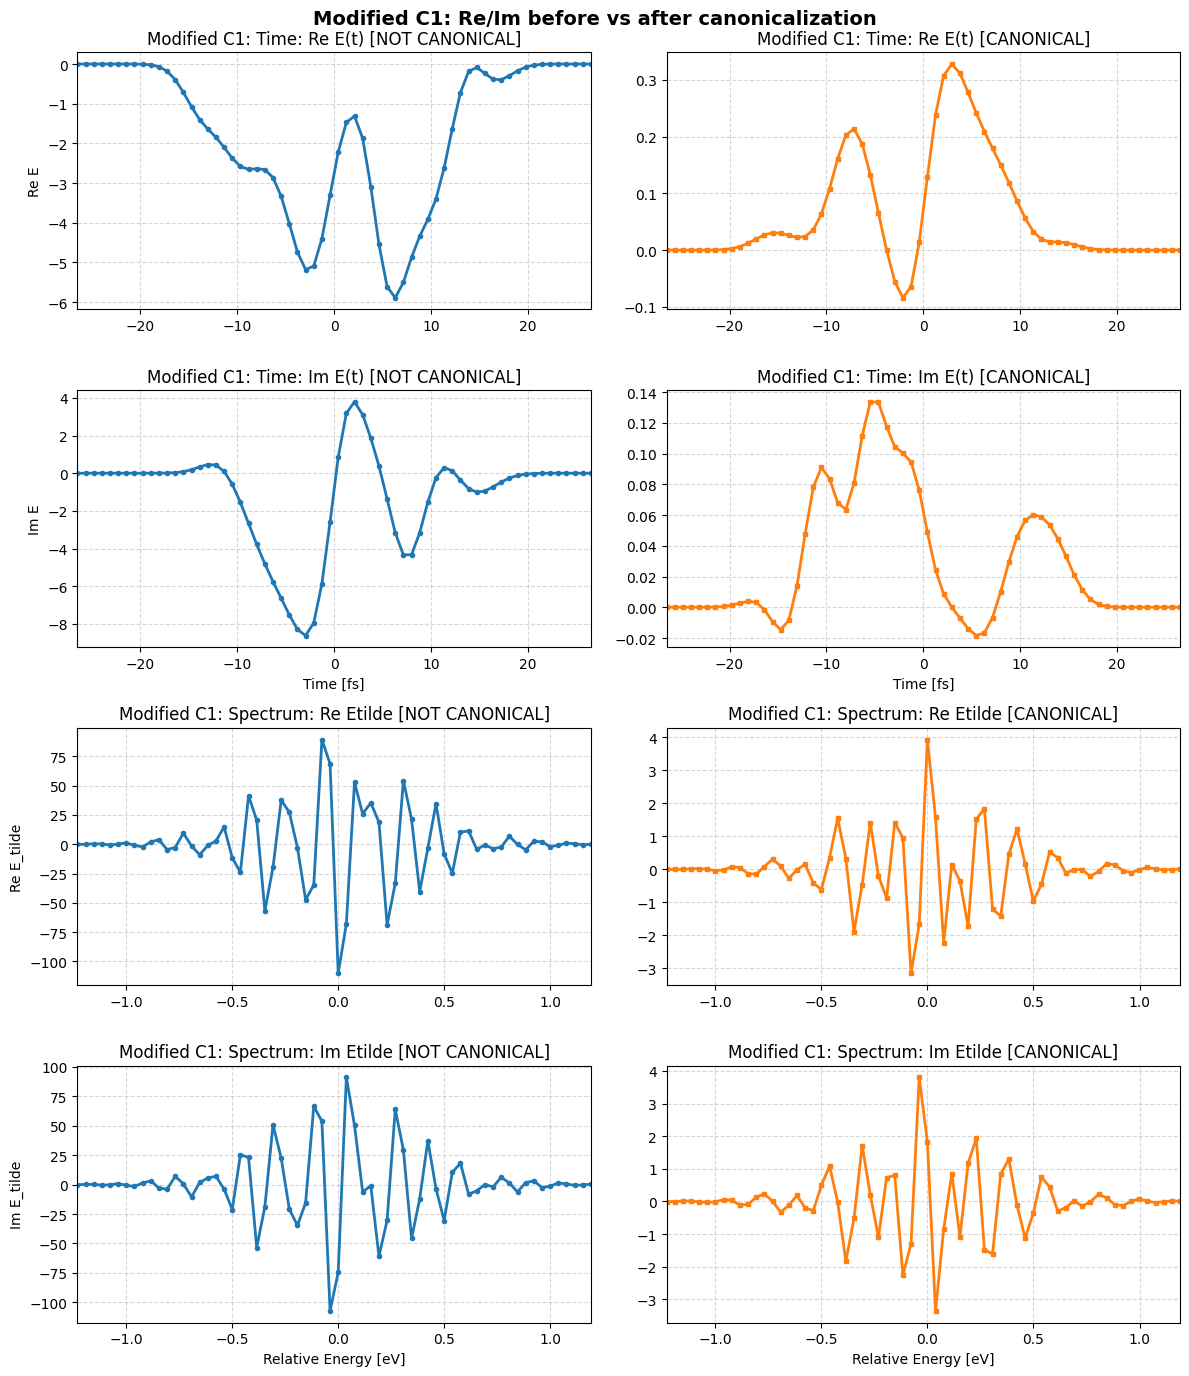

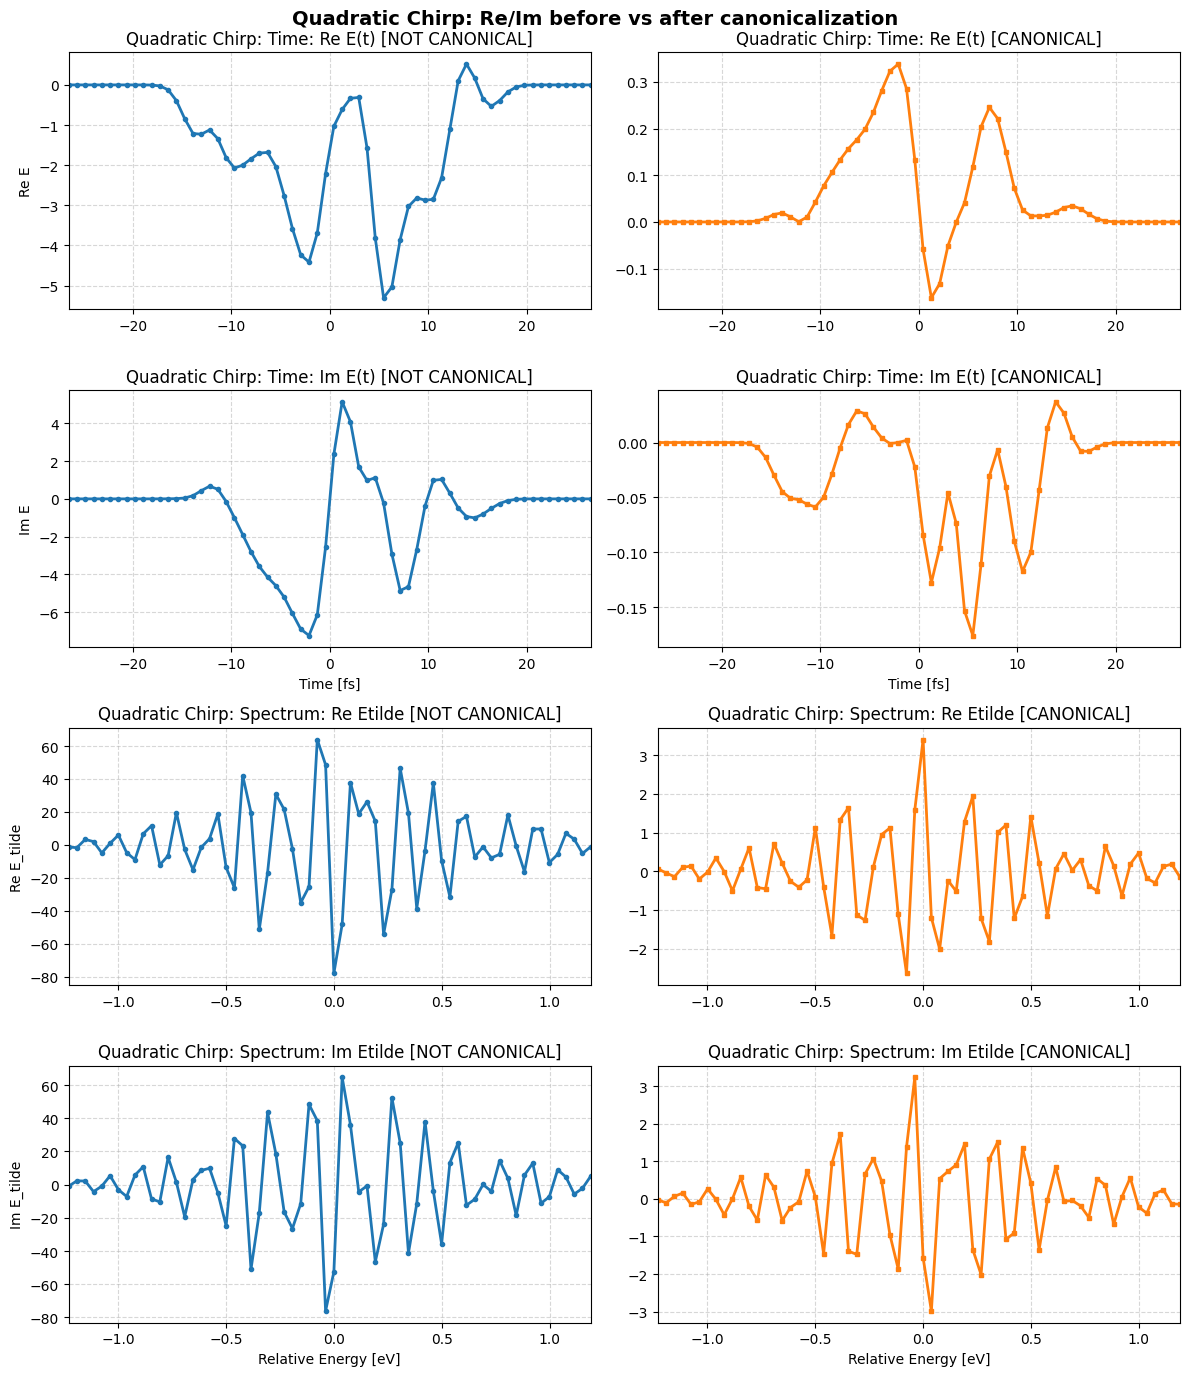

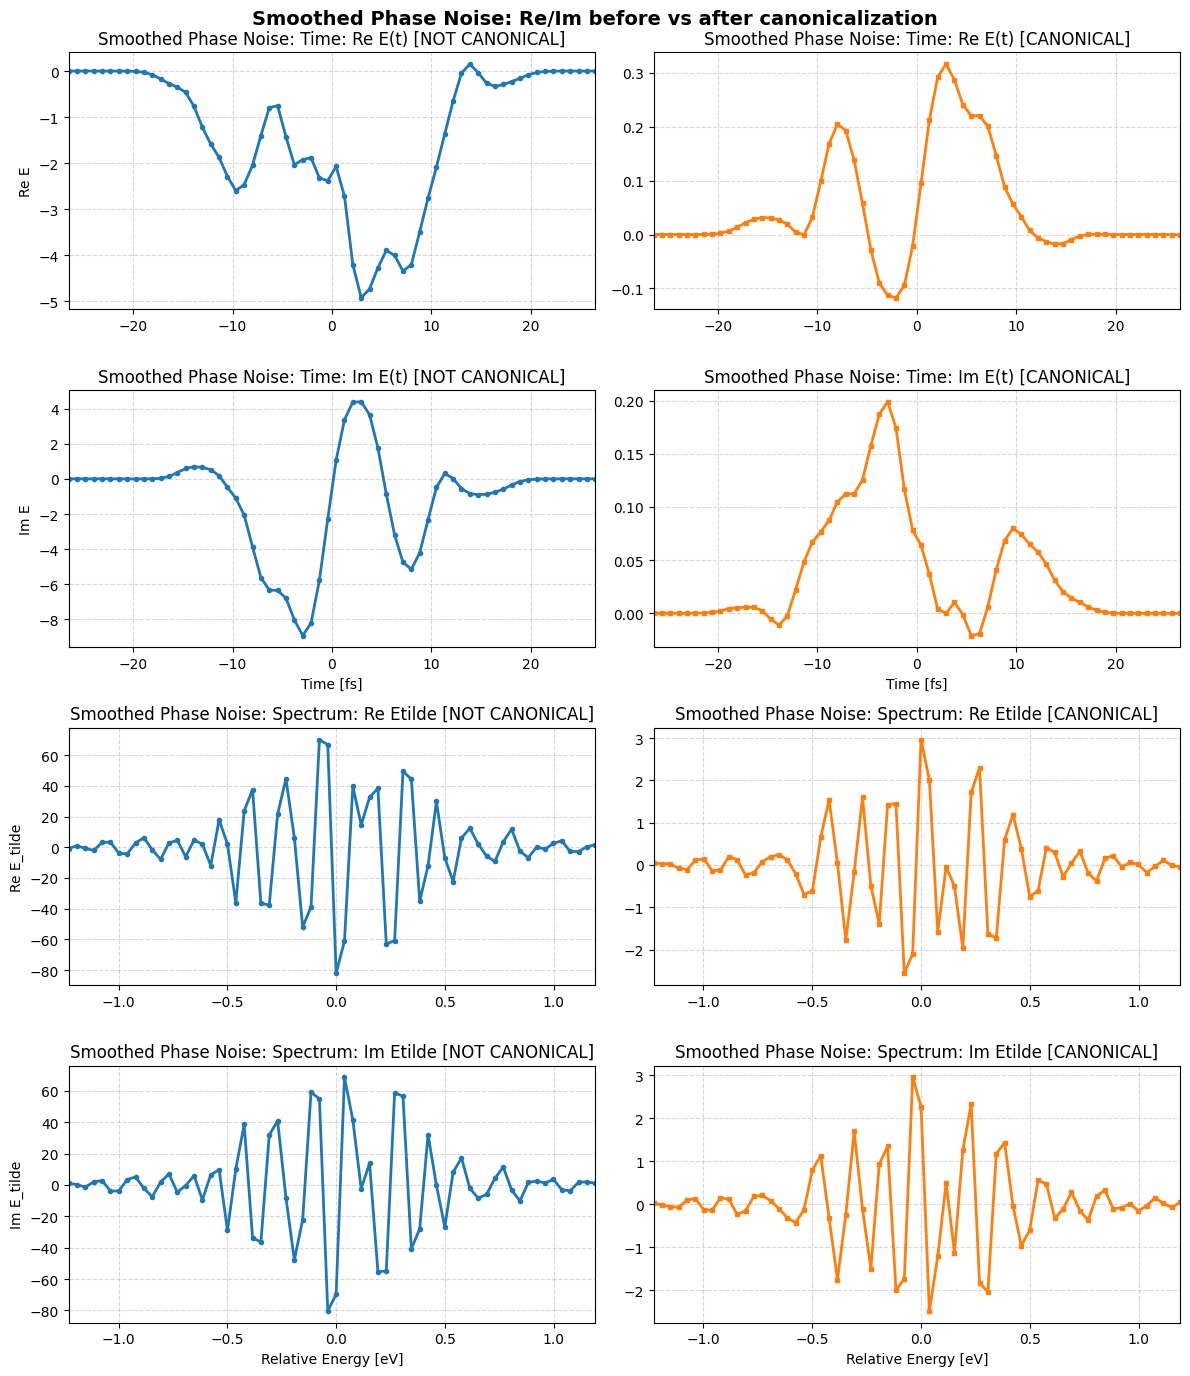

In [3]:
def plot_reim_before_after(
    f_t_raw,
    f_t_canon,
    f_v_raw,
    f_v_canon,
    model_label,
):
    """4x2 grid: time/frequency x Re/Im, raw (left) vs canonical (right)."""
    # Do NOT sharex across time vs frequency — different physical axes.
    fig, axs = plt.subplots(4, 2, figsize=(12, 14))
    e_lo, e_hi = float(energy_ev_relative[0]), float(energy_ev_relative[-1])
    t_lo, t_hi = float(t[0]), float(t[-1])

    pairs = [
        ("Time: Re E(t)", t, np.real(f_t_raw), np.real(f_t_canon), "Time [fs]", "Re E", (t_lo, t_hi)),
        ("Time: Im E(t)", t, np.imag(f_t_raw), np.imag(f_t_canon), "Time [fs]", "Im E", (t_lo, t_hi)),
        (
            "Spectrum: Re Etilde",
            energy_ev_relative,
            np.real(f_v_raw),
            np.real(f_v_canon),
            "Relative Energy [eV]",
            "Re E_tilde",
            (e_lo, e_hi),
        ),
        (
            "Spectrum: Im Etilde",
            energy_ev_relative,
            np.imag(f_v_raw),
            np.imag(f_v_canon),
            "Relative Energy [eV]",
            "Im E_tilde",
            (e_lo, e_hi),
        ),
    ]
    for row, (title, x, y_raw, y_canon, xlabel, ylabel, xlim) in enumerate(pairs):
        axs[row, 0].plot(x, y_raw, color="tab:blue", lw=2, marker="o", markersize=3)
        axs[row, 0].set_title(f"{model_label}: {title} [NOT CANONICAL]")
        axs[row, 0].set_ylabel(ylabel)
        axs[row, 0].set_xlim(*xlim)
        axs[row, 0].grid(True, linestyle="--", alpha=0.5)

        axs[row, 1].plot(x, y_canon, color="tab:orange", lw=2, marker="s", markersize=3)
        axs[row, 1].set_title(f"{model_label}: {title} [CANONICAL]")
        axs[row, 1].set_xlim(*xlim)
        axs[row, 1].grid(True, linestyle="--", alpha=0.5)

        if row in (1, 3):
            axs[row, 0].set_xlabel(xlabel)
            axs[row, 1].set_xlabel(xlabel)

    fig.suptitle(f"{model_label}: Re/Im before vs after canonicalization", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


reim_models = {
    "modified_c1": (
        f_t_modified_raw,
        f_t_modified,
        f_v_modified_raw,
        f_v_modified,
        "Modified C1",
    ),
    "quadratic_chirp": (
        f_t_quadratic_raw,
        f_t_quadratic,
        f_v_quadratic_raw,
        f_v_quadratic,
        "Quadratic Chirp",
    ),
    "smoothed_phase_noise": (
        f_t_smoothed_raw,
        f_t_smoothed,
        f_v_smoothed_raw,
        f_v_smoothed,
        "Smoothed Phase Noise",
    ),
}

if FIELD_TO_PLOT == "all":
    for key in ("modified_c1", "quadratic_chirp", "smoothed_phase_noise"):
        plot_reim_before_after(*reim_models[key])
elif FIELD_TO_PLOT == "both":
    plot_reim_before_after(*reim_models["modified_c1"])
    plot_reim_before_after(*reim_models["quadratic_chirp"])
else:
    plot_reim_before_after(*reim_models[FIELD_TO_PLOT])


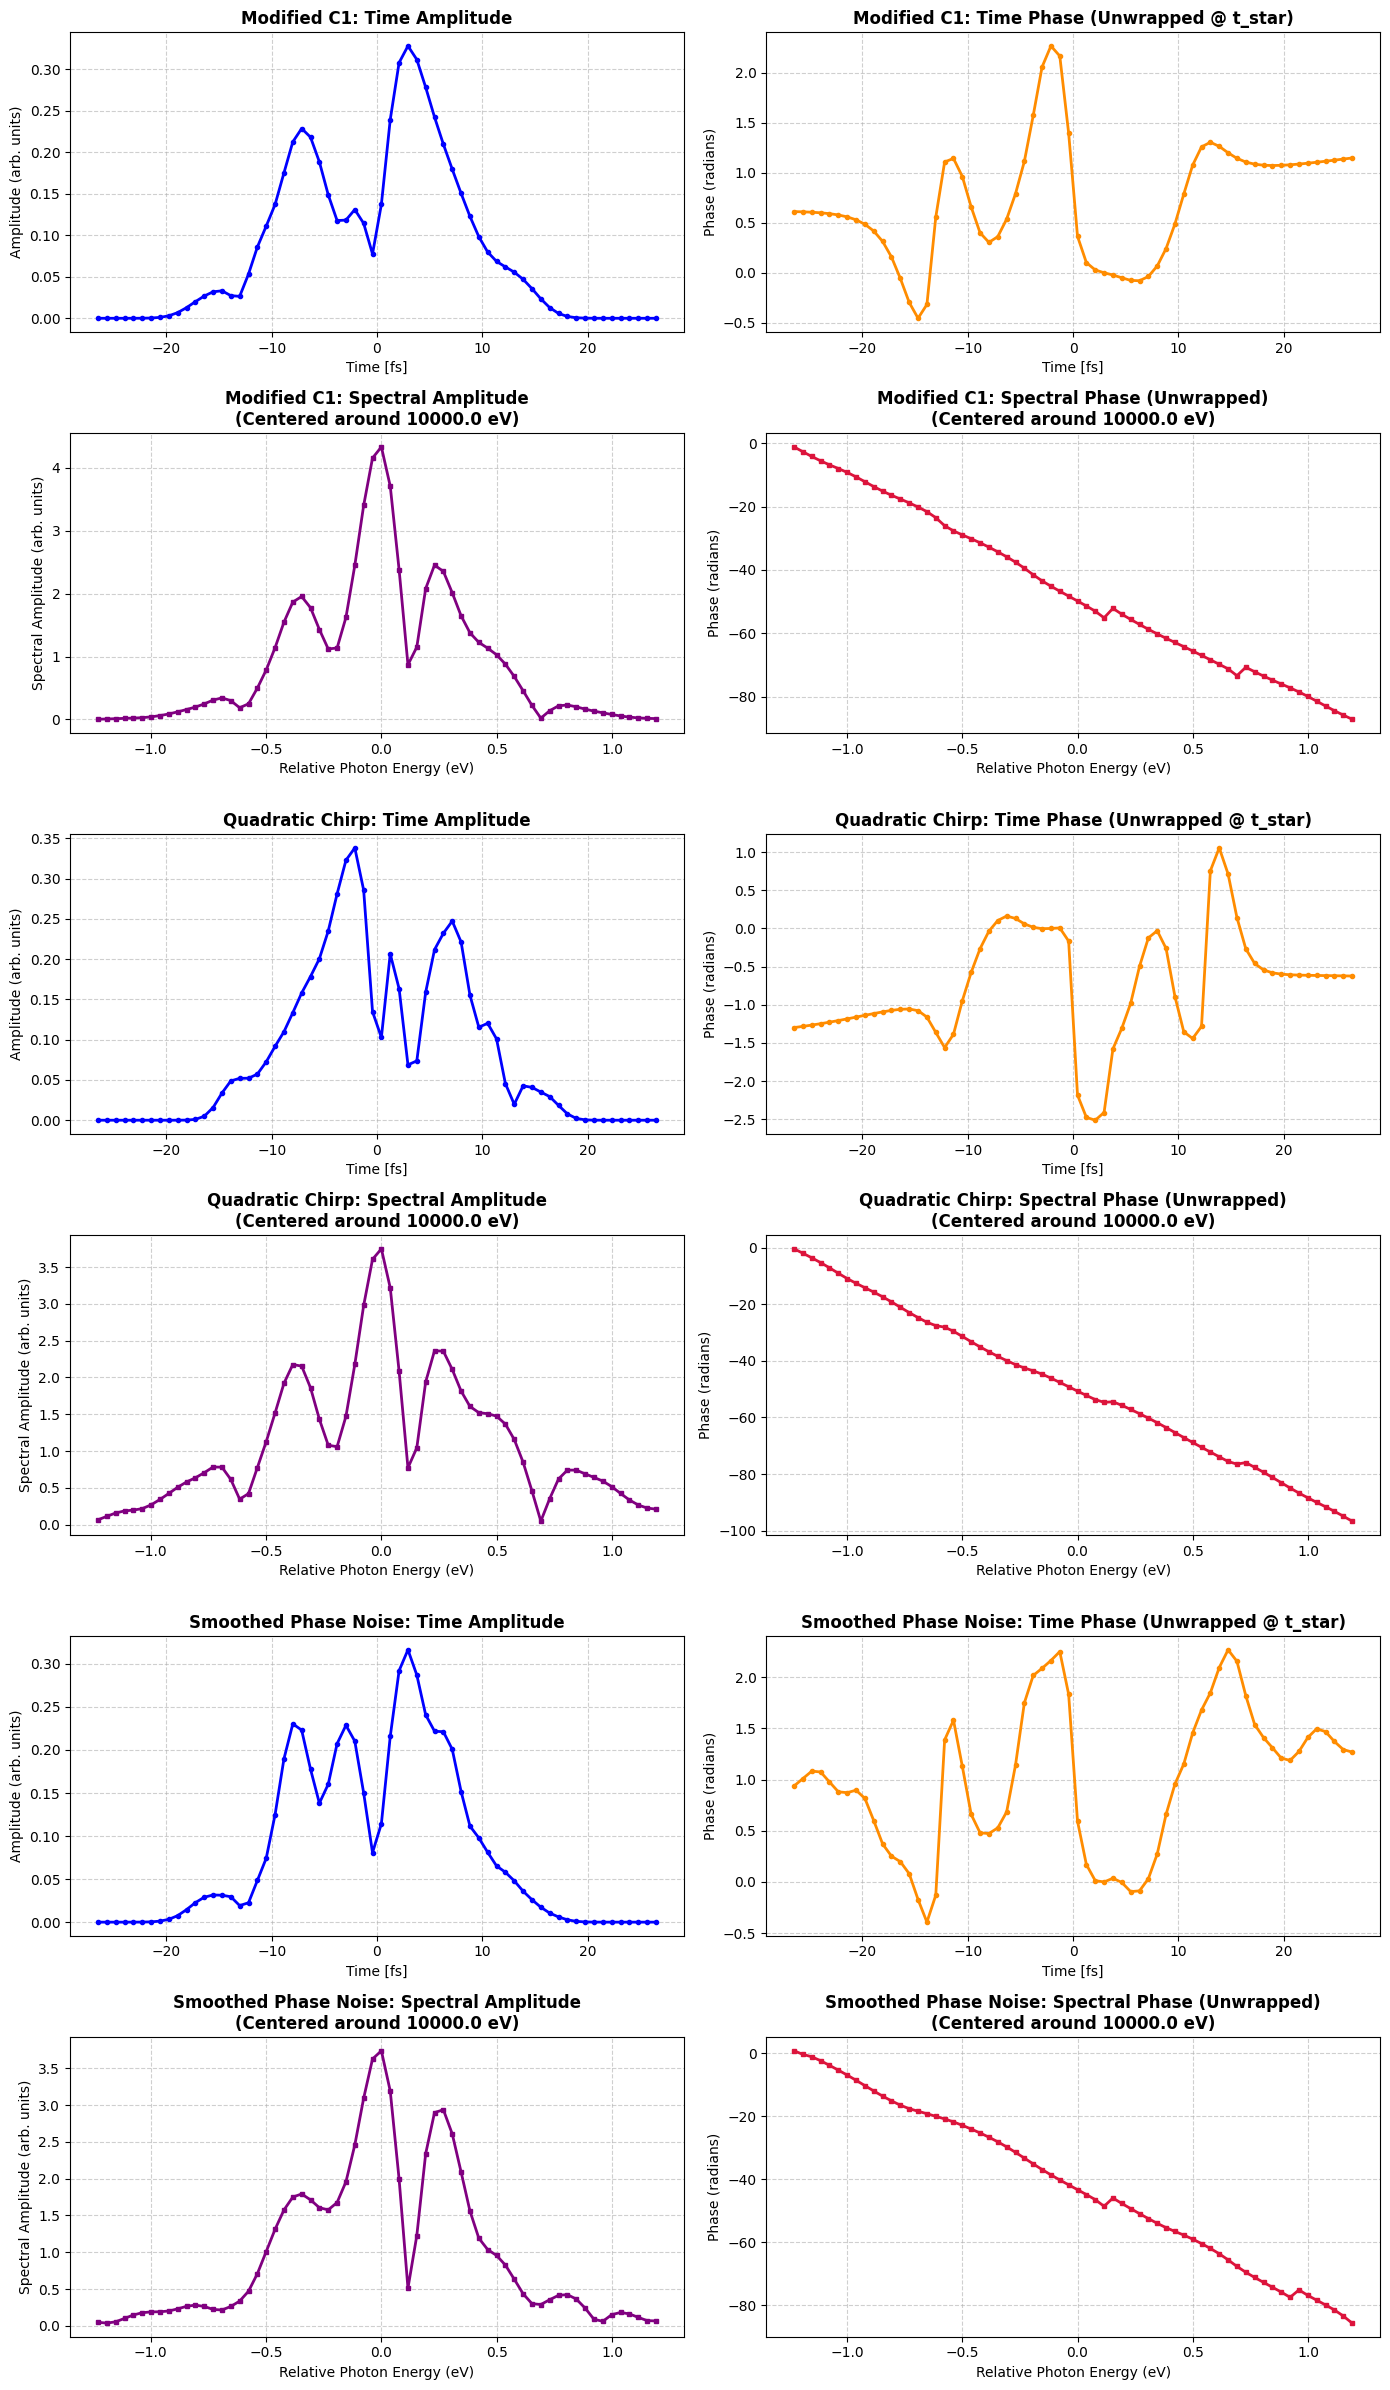

In [4]:
def plot_field_domain_panels(axs_block, f_t_field, f_v_field, model_label, t_star_idx):
    """Plot 2x2 amplitude/phase panels for one field model."""
    amplitude_t = np.abs(f_t_field)
    phase_t = phase_t_unwrapped_at_index(f_t_field, t_star_idx)
    amplitude_v = np.abs(f_v_field)
    phase_v = np.unwrap(np.angle(f_v_field))

    axs_block[0, 0].plot(t, amplitude_t, color='blue', lw=2, marker='o', markersize=3)
    axs_block[0, 0].set_title(f'{model_label}: Time Amplitude', fontsize=12, fontweight='bold')
    axs_block[0, 0].set_xlabel('Time [fs]', fontsize=10)
    axs_block[0, 0].set_ylabel('Amplitude (arb. units)', fontsize=10)
    axs_block[0, 0].grid(True, linestyle='--', alpha=0.6)

    axs_block[0, 1].plot(t, phase_t, color='darkorange', lw=2, marker='o', markersize=3)
    axs_block[0, 1].set_title(f'{model_label}: Time Phase (Unwrapped @ t_star)', fontsize=12, fontweight='bold')
    axs_block[0, 1].set_xlabel('Time [fs]', fontsize=10)
    axs_block[0, 1].set_ylabel('Phase (radians)', fontsize=10)
    axs_block[0, 1].grid(True, linestyle='--', alpha=0.6)

    axs_block[1, 0].plot(energy_ev_relative, amplitude_v, color='purple', lw=2, marker='s', markersize=3)
    axs_block[1, 0].set_title(
        f'{model_label}: Spectral Amplitude\n(Centered around {CENTRAL_ENERGY_EV} eV)',
        fontsize=12,
        fontweight='bold',
    )
    axs_block[1, 0].set_xlabel('Relative Photon Energy (eV)', fontsize=10)
    axs_block[1, 0].set_ylabel('Spectral Amplitude (arb. units)', fontsize=10)
    axs_block[1, 0].grid(True, linestyle='--', alpha=0.6)

    axs_block[1, 1].plot(energy_ev_relative, phase_v, color='crimson', lw=2, marker='s', markersize=3)
    axs_block[1, 1].set_title(
        f'{model_label}: Spectral Phase (Unwrapped)\n(Centered around {CENTRAL_ENERGY_EV} eV)',
        fontsize=12,
        fontweight='bold',
    )
    axs_block[1, 1].set_xlabel('Relative Photon Energy (eV)', fontsize=10)
    axs_block[1, 1].set_ylabel('Phase (radians)', fontsize=10)
    axs_block[1, 1].grid(True, linestyle='--', alpha=0.6)


field_models = {
    "modified_c1": (f_t_modified, f_v_modified, "Modified C1"),
    "quadratic_chirp": (f_t_quadratic, f_v_quadratic, "Quadratic Chirp"),
    "smoothed_phase_noise": (f_t_smoothed, f_v_smoothed, "Smoothed Phase Noise"),
}

if FIELD_TO_PLOT == "all":
    fig, axs = plt.subplots(6, 2, figsize=(14, 24))
    plot_field_domain_panels(axs[0:2, :], f_t_modified, f_v_modified, "Modified C1", t_star_modified)
    plot_field_domain_panels(axs[2:4, :], f_t_quadratic, f_v_quadratic, "Quadratic Chirp", t_star_quadratic)
    plot_field_domain_panels(axs[4:6, :], f_t_smoothed, f_v_smoothed, "Smoothed Phase Noise", t_star_smoothed)
elif FIELD_TO_PLOT == "both":
    fig, axs = plt.subplots(4, 2, figsize=(14, 16))
    plot_field_domain_panels(axs[0:2, :], f_t_modified, f_v_modified, "Modified C1", t_star_modified)
    plot_field_domain_panels(axs[2:4, :], f_t_quadratic, f_v_quadratic, "Quadratic Chirp", t_star_quadratic)
else:
    f_t_sel, f_v_sel, label = field_models[FIELD_TO_PLOT]
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    t_star_sel = {"modified_c1": t_star_modified, "quadratic_chirp": t_star_quadratic, "smoothed_phase_noise": t_star_smoothed}[FIELD_TO_PLOT]
    plot_field_domain_panels(axs, f_t_sel, f_v_sel, label, t_star_sel)

plt.tight_layout()
plt.show()

## Raw Pulses — **NOT CANONICAL** (before `canonicalize_field_tstar`)

> **Plots below:** `f_t_*_raw` **before** ambiguity removal — arbitrary global phase, scale, and time direction. Includes raw time-domain panels and raw SHG-FROG traces.

| Quantity | Raw | Canonical (`canonicalize_field_tstar`) |
|----------|-----|----------------------------------------|
| Amplitude | $\|E\|$, $\|E\|_2$ in title | L2-normalized $\|E\|$ |
| Phase | $\mathrm{unwrap}(\arg E)$ | `phase_t_unwrapped_at_index` at $t_*$ |
| Peak anchor | — | $t_* = \arg\max_t |E(t)|$ |


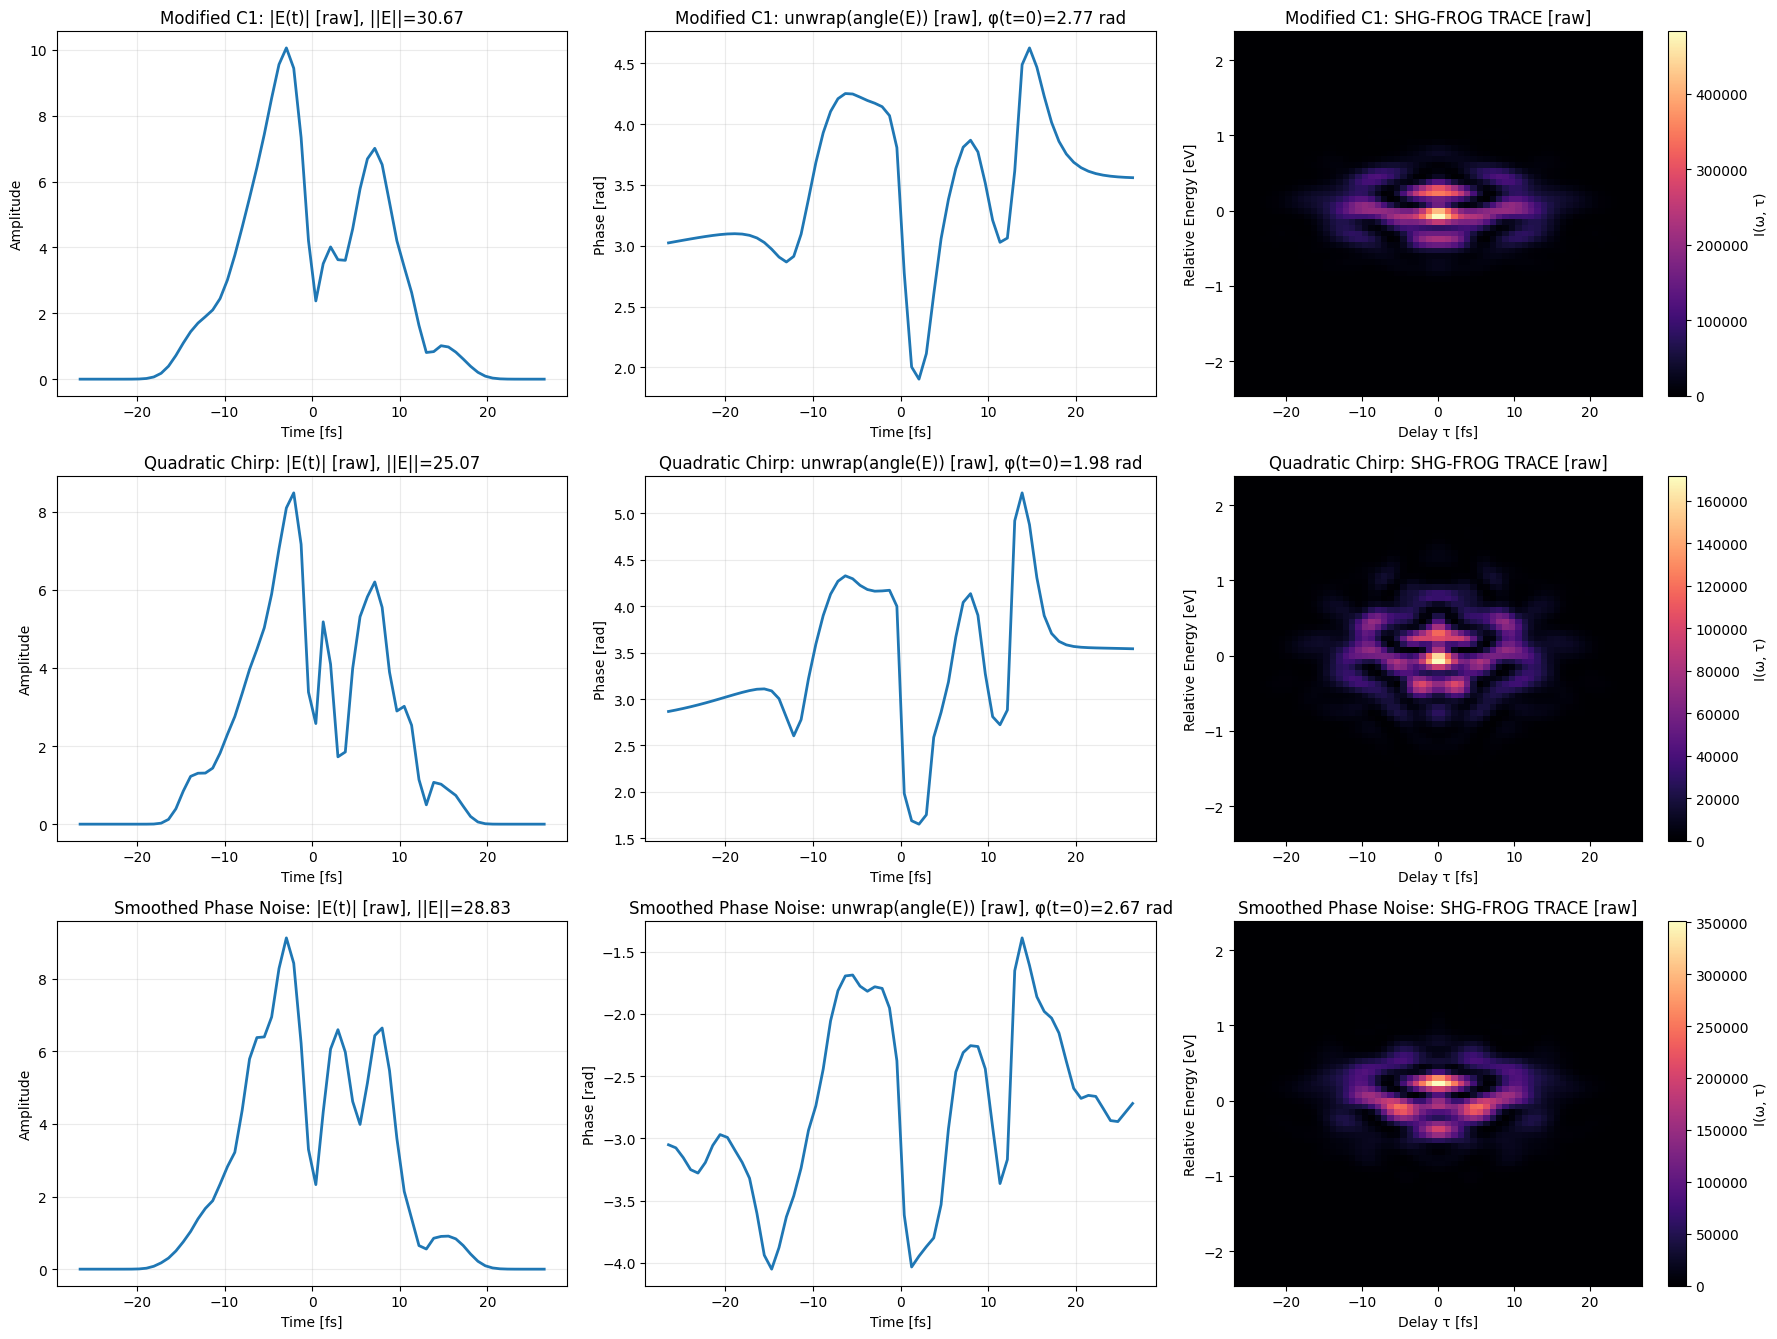

In [5]:
import torch

from frognet import FROGNet
from pulse_metrics import prepare_frog_trace_for_plot


def compute_frog_trace_raw(f_t_field):
    frog = FROGNet(num_delay_steps=len(t))
    frog.eval()
    e_t_torch = torch.from_numpy(f_t_field.astype(np.complex64)).unsqueeze(0)
    with torch.no_grad():
        return frog(e_t_torch).squeeze(0).cpu().numpy()


def plot_frog_row_raw(fig, axes_row, f_t_field, model_label):
    trace = compute_frog_trace_raw(f_t_field)
    trace_plot, tau_axis, omega_plot = prepare_frog_trace_for_plot(
        trace,
        num_points=N_POINTS,
        dt=dt,
    )
    energy_plot = omega_plot * PLANCK_CONSTANT_FS_EV / (2.0 * np.pi)

    amp_t = np.abs(f_t_field)
    phase_t_plot = np.unwrap(np.angle(f_t_field))  # do NOT re-anchor at t=0
    phi0 = np.angle(f_t_field[zero_index])
    e_norm = np.linalg.norm(f_t_field)

    axes_row[0].plot(t, amp_t, lw=2)
    axes_row[0].set_title(f"{model_label}: |E(t)| [raw], ||E||={e_norm:.2f}")
    axes_row[0].set_xlabel("Time [fs]")
    axes_row[0].set_ylabel("Amplitude")
    axes_row[0].grid(alpha=0.25)

    axes_row[1].plot(t, phase_t_plot, lw=2)
    axes_row[1].set_title(f"{model_label}: unwrap(angle(E)) [raw], φ(t=0)={phi0:.2f} rad")
    axes_row[1].set_xlabel("Time [fs]")
    axes_row[1].set_ylabel("Phase [rad]")
    axes_row[1].grid(alpha=0.25)

    im = axes_row[2].imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
        cmap="magma",
    )
    axes_row[2].set_title(f"{model_label}: SHG-FROG TRACE [raw]")
    axes_row[2].set_xlabel("Delay τ [fs]")
    axes_row[2].set_ylabel("Relative Energy [eV]")
    fig.colorbar(im, ax=axes_row[2], label="I(ω, τ)")


frog_models_raw = {
    "modified_c1": (f_t_modified_raw, "Modified C1"),
    "quadratic_chirp": (f_t_quadratic_raw, "Quadratic Chirp"),
    "smoothed_phase_noise": (f_t_smoothed_raw, "Smoothed Phase Noise"),
}

if FIELD_TO_PLOT == "all":
    fig, axes = plt.subplots(3, 3, figsize=(18, 13.5))
    plot_frog_row_raw(fig, axes[0], f_t_modified_raw, "Modified C1")
    plot_frog_row_raw(fig, axes[1], f_t_quadratic_raw, "Quadratic Chirp")
    plot_frog_row_raw(fig, axes[2], f_t_smoothed_raw, "Smoothed Phase Noise")
elif FIELD_TO_PLOT == "both":
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    plot_frog_row_raw(fig, axes[0], f_t_modified_raw, "Modified C1")
    plot_frog_row_raw(fig, axes[1], f_t_quadratic_raw, "Quadratic Chirp")
else:
    f_t_sel_raw, label = frog_models_raw[FIELD_TO_PLOT]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    plot_frog_row_raw(fig, axes, f_t_sel_raw, label)

plt.tight_layout()
plt.show()

## SHG-FROG Spectrogram (legacy `FROGNet`) — **CANONICAL** input fields

> **Plots below:** SHG-FROG traces from **canonical** `f_t_*` (after `canonicalize_field_tstar`). Legacy 64-pt spectral axis.

$$I(\omega,\tau) = \left|\mathrm{FFT}_t\big[E(t)\,E(t-\tau)\big]\right|^2$$

Uses the **original** 64-point FFT inside `FROGNet` — coarser spectral axis than the padded pipeline.

| Axis | Symbol | Code | What it represents |
|------|--------|------|--------------------|
| Frequency | $\omega \leftrightarrow E$ | `energy_plot` | Relative photon energy; full $N=64$ bins, $\Delta E \approx 0.077$ eV |
| Delay | $\tau$ | `tau_axis` | Inter-pulse delay (fs); one value per row |
| Intensity | $I$ | `trace_plot` | SHG-FROG trace intensity (arb. units) |

See **FROGNetPadded** below for the matched $E_{\mathrm{rel}}$ grid ($\Delta E \approx 0.037$ eV).


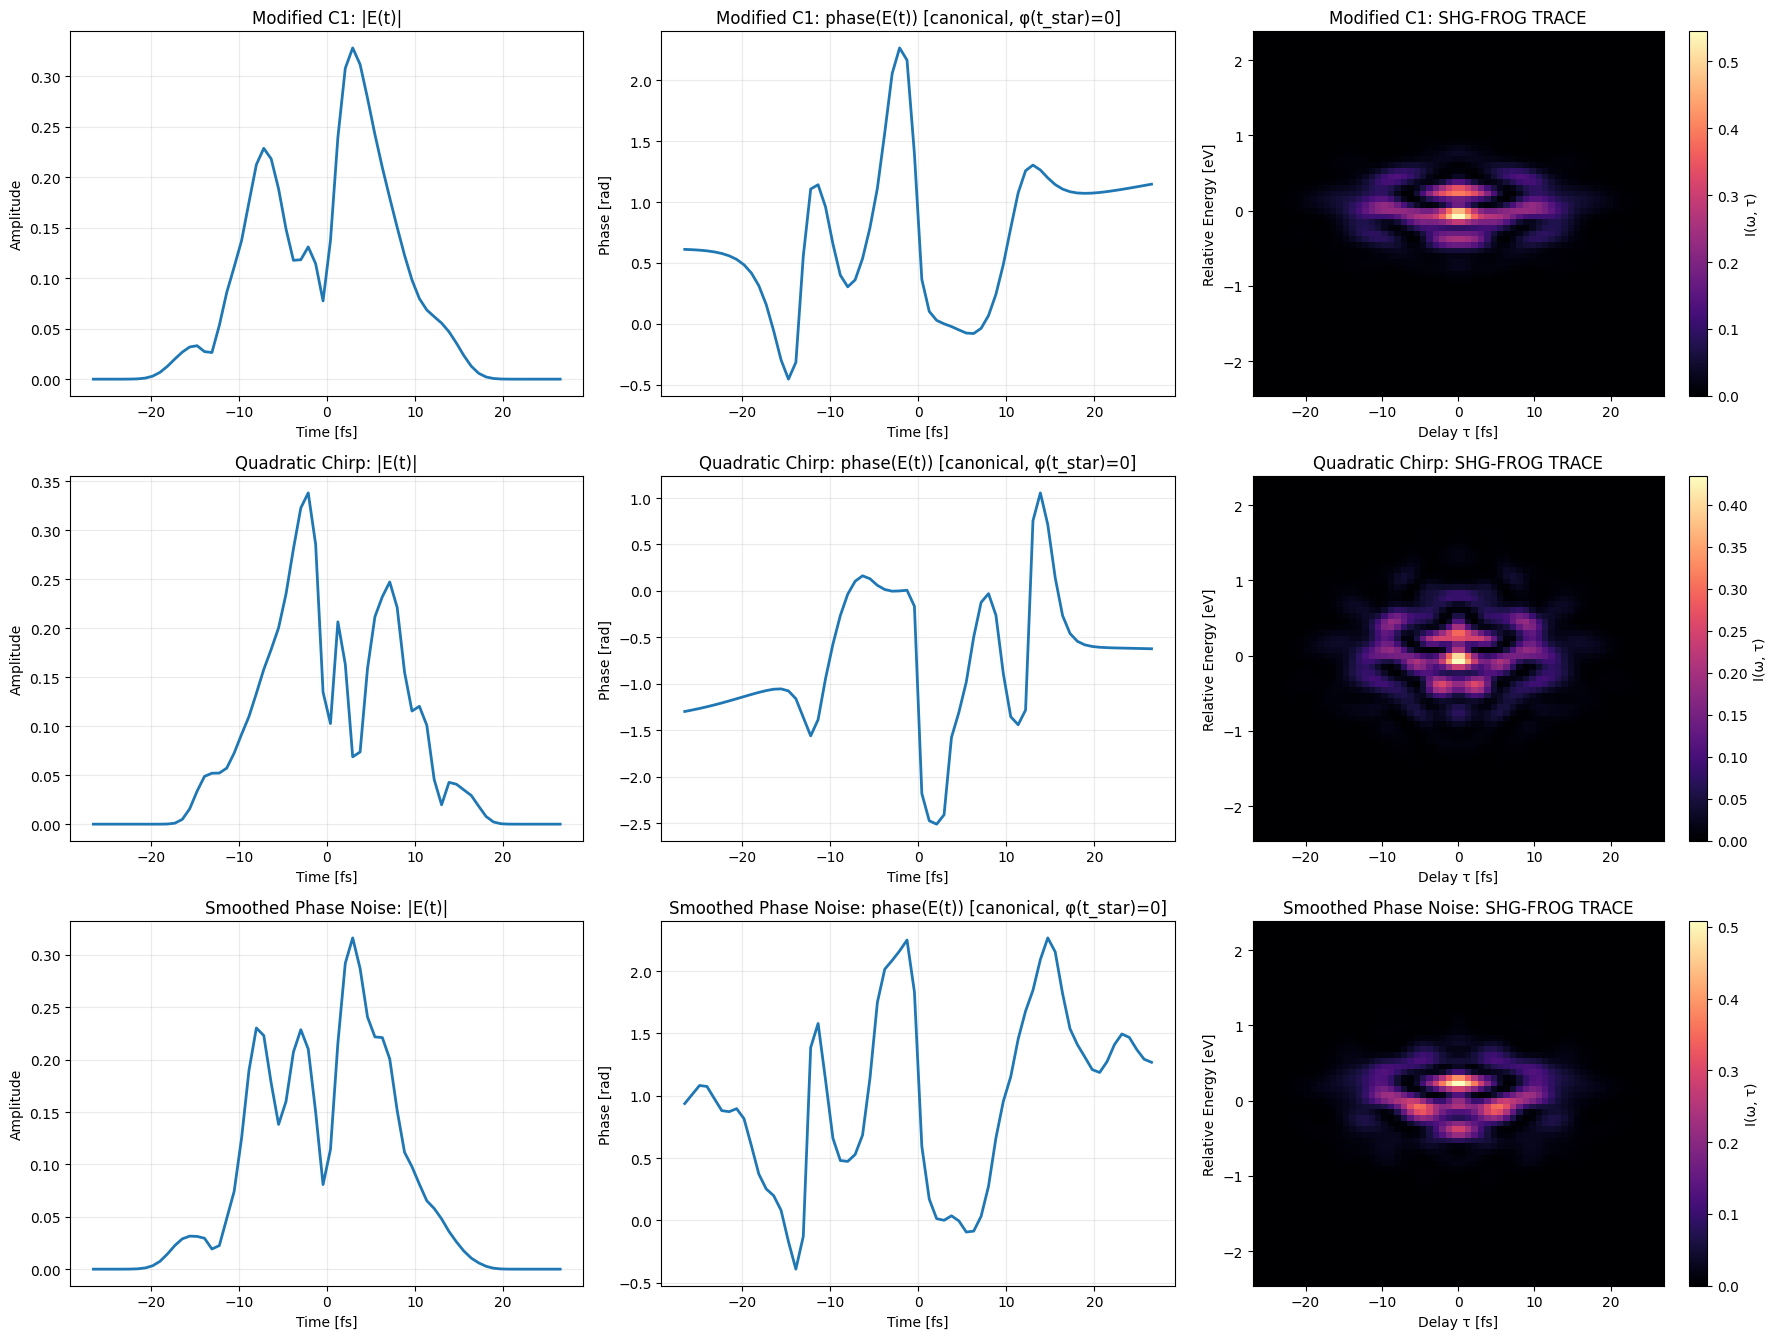

In [6]:
import torch

from data_generation import phase_t_unwrapped_at_index

from frognet import FROGNet
from pulse_metrics import prepare_frog_trace_for_plot


def compute_frog_trace(f_t_field):
    frog = FROGNet(num_delay_steps=len(t))
    frog.eval()
    e_t_torch = torch.from_numpy(f_t_field.astype(np.complex64)).unsqueeze(0)
    with torch.no_grad():
        return frog(e_t_torch).squeeze(0).cpu().numpy()


def plot_frog_row(fig, axes_row, f_t_field, model_label):
    trace = compute_frog_trace(f_t_field)
    trace_plot, tau_axis, omega_plot = prepare_frog_trace_for_plot(
        trace,
        num_points=N_POINTS,
        dt=dt,
    )
    energy_plot = omega_plot * PLANCK_CONSTANT_FS_EV / (2.0 * np.pi)

    amp_t = np.abs(f_t_field)
    t_star_idx = int(np.argmax(np.abs(f_t_field)))
    phase_t_plot = phase_t_unwrapped_at_index(f_t_field, t_star_idx)

    axes_row[0].plot(t, amp_t, lw=2)
    axes_row[0].set_title(f"{model_label}: |E(t)|")
    axes_row[0].set_xlabel("Time [fs]")
    axes_row[0].set_ylabel("Amplitude")
    axes_row[0].grid(alpha=0.25)

    axes_row[1].plot(t, phase_t_plot, lw=2)
    axes_row[1].set_title(f"{model_label}: phase(E(t)) [canonical, φ(t_star)=0]")
    axes_row[1].set_xlabel("Time [fs]")
    axes_row[1].set_ylabel("Phase [rad]")
    axes_row[1].grid(alpha=0.25)

    im = axes_row[2].imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
        cmap="magma",
    )
    axes_row[2].set_title(f"{model_label}: SHG-FROG TRACE")
    axes_row[2].set_xlabel("Delay τ [fs]")
    axes_row[2].set_ylabel("Relative Energy [eV]")
    fig.colorbar(im, ax=axes_row[2], label="I(ω, τ)")


frog_models = {
    "modified_c1": (f_t_modified, "Modified C1"),
    "quadratic_chirp": (f_t_quadratic, "Quadratic Chirp"),
    "smoothed_phase_noise": (f_t_smoothed, "Smoothed Phase Noise"),
}

if FIELD_TO_PLOT == "all":
    fig, axes = plt.subplots(3, 3, figsize=(18, 13.5))
    plot_frog_row(fig, axes[0], f_t_modified, "Modified C1")
    plot_frog_row(fig, axes[1], f_t_quadratic, "Quadratic Chirp")
    plot_frog_row(fig, axes[2], f_t_smoothed, "Smoothed Phase Noise")
elif FIELD_TO_PLOT == "both":
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    plot_frog_row(fig, axes[0], f_t_modified, "Modified C1")
    plot_frog_row(fig, axes[1], f_t_quadratic, "Quadratic Chirp")
else:
    f_t_sel, label = frog_models[FIELD_TO_PLOT]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    plot_frog_row(fig, axes, f_t_sel, label)

plt.tight_layout()
plt.show()

## SHG-FROG with Matched Spectral Grid (`FROGNetPadded`) — **CANONICAL** input fields

> **Plots below:** padded FROG from **canonical** `f_t_*`; spectral axis matches `energy_ev_relative`.

$$\mathrm{FFT}_t \rightarrow N_{\mathrm{fft}}=128, \qquad \mathrm{crop}\rightarrow N_{\mathrm{spec}}=64$$

Same spectral grid as the field plots: zero-pad FFT to 128, keep central 64 frequency rows.

| Symbol | Code name | What it represents |
|--------|-----------|--------------------|
| model | `FROGNetPadded` | FROG module in `frognet_padded.py` |
| $N_{\mathrm{fft}}$ | `N_FFT` | FFT length along time in FROG (128, even) |
| $N_{\mathrm{spec}}$ | `N_SPECTRAL_POINTS` | Frequency rows in output trace (64) |
| $E_{\mathrm{rel}}$ | `energy_ev_relative` | Y-axis: relative photon energy (eV) |
| $\tau$ | `tau_axis` | X-axis: delay (fs) |
| trace | `trace_plot` | Intensity $I(\omega,\tau)$ on the cropped grid |
| spacing | `DE_NEW_ACTUAL` | $\approx 0.0367$ eV between adjacent frequency rows |


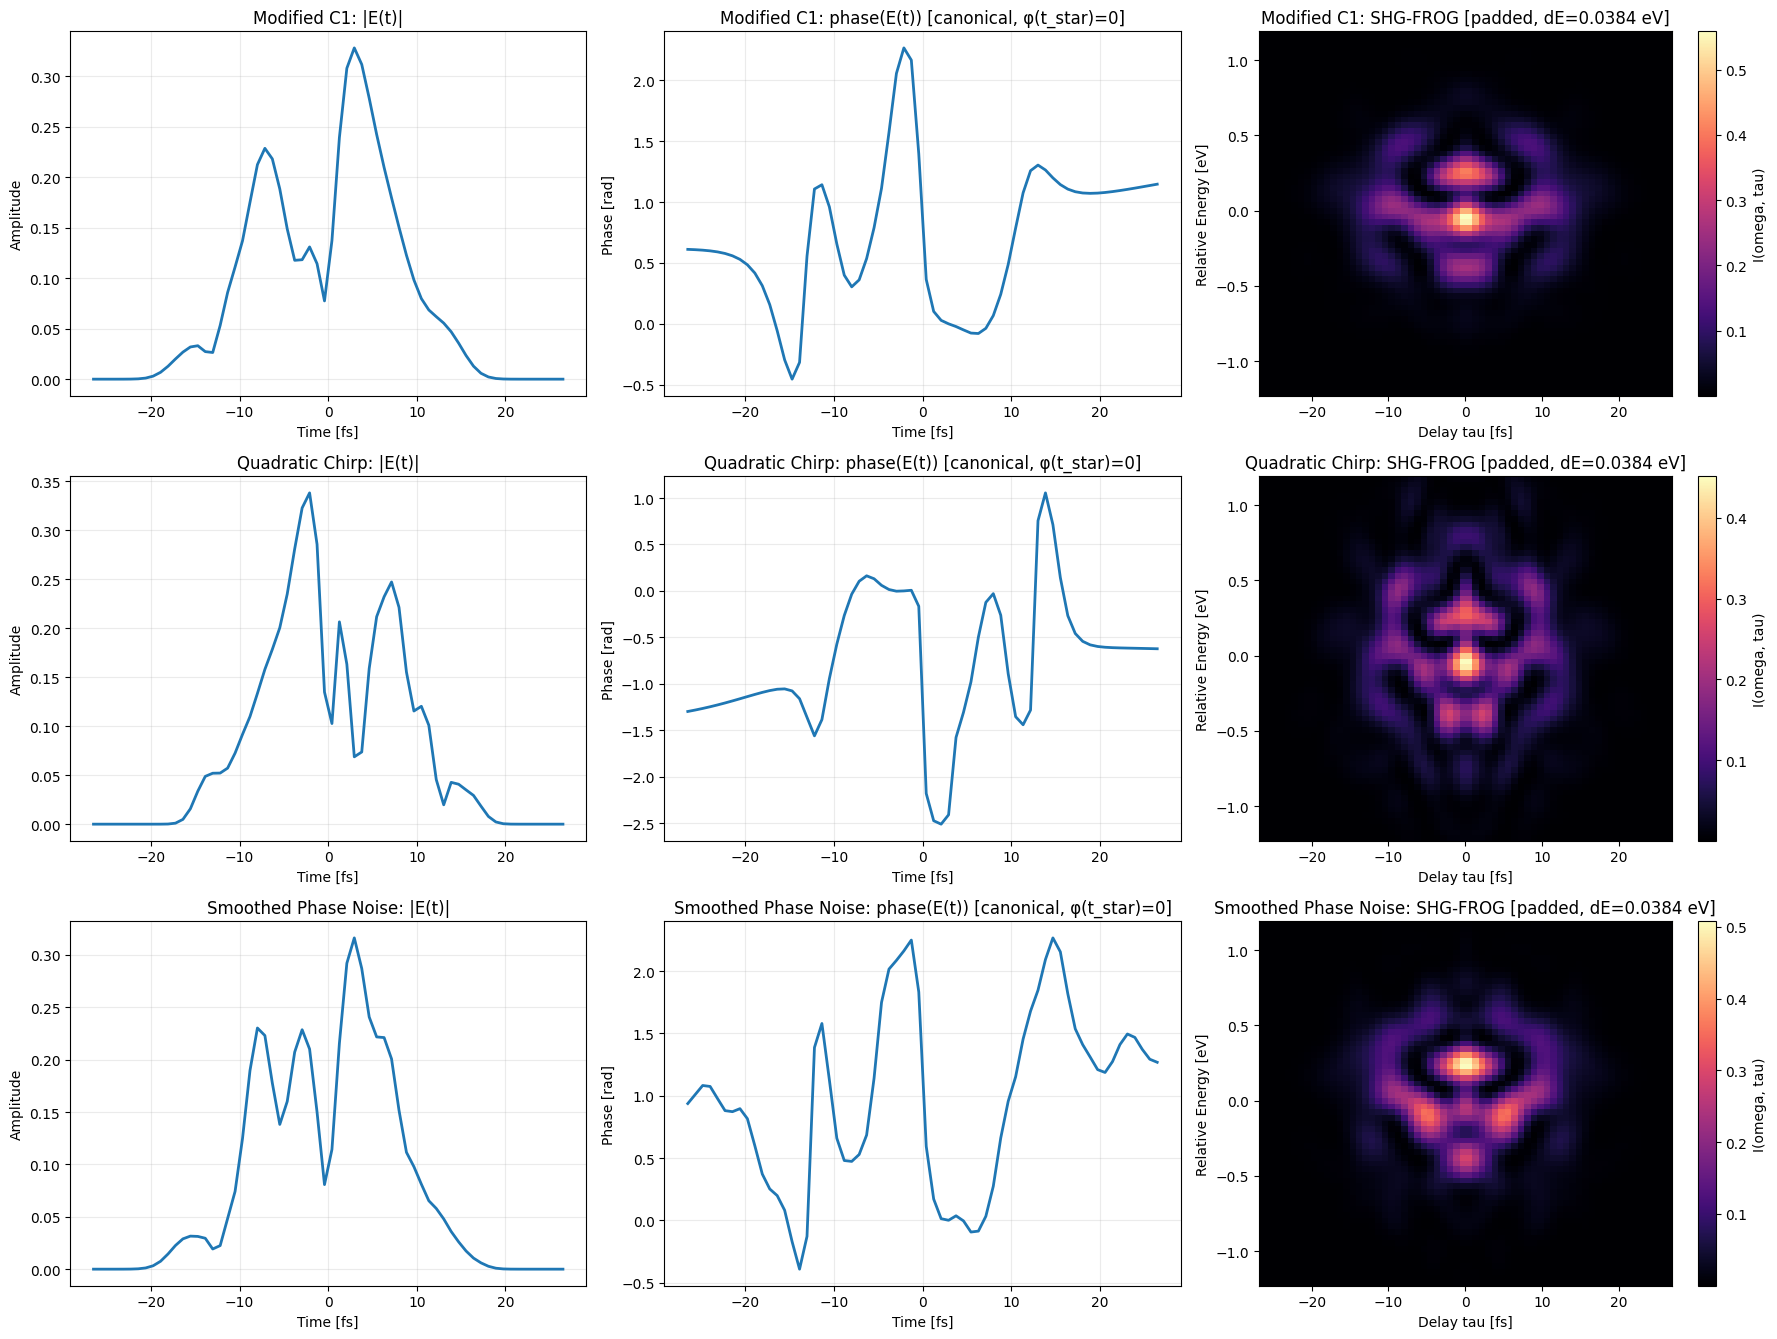

In [7]:
import torch

from data_generation import phase_t_unwrapped_at_index

from frognet_padded import FROGNetPadded
from pulse_metrics import prepare_frog_trace_for_plot


_frog_padded = FROGNetPadded(
    num_delay_steps=len(t),
    n_fft=N_FFT,
    n_spectral_points=N_SPECTRAL_POINTS,
)
_frog_padded.eval()


def compute_frog_trace_padded(f_t_field):
    e_t_torch = torch.from_numpy(f_t_field.astype(np.complex64)).unsqueeze(0)
    with torch.no_grad():
        return _frog_padded(e_t_torch).squeeze(0).cpu().numpy()


def _frog_tau_axis():
    _, tau_axis, _ = prepare_frog_trace_for_plot(
        np.zeros((N_POINTS, len(t))), num_points=N_POINTS, dt=dt
    )
    return tau_axis


def plot_frog_row_padded(fig, axes_row, f_t_field, model_label):
    trace_plot = compute_frog_trace_padded(f_t_field)
    tau_axis = _frog_tau_axis()
    energy_plot = energy_ev_relative

    amp_t = np.abs(f_t_field)
    t_star_idx = int(np.argmax(np.abs(f_t_field)))
    phase_t_plot = phase_t_unwrapped_at_index(f_t_field, t_star_idx)

    axes_row[0].plot(t, amp_t, lw=2)
    axes_row[0].set_title(f"{model_label}: |E(t)|")
    axes_row[0].set_xlabel("Time [fs]")
    axes_row[0].set_ylabel("Amplitude")
    axes_row[0].grid(alpha=0.25)

    axes_row[1].plot(t, phase_t_plot, lw=2)
    axes_row[1].set_title(f"{model_label}: phase(E(t)) [canonical, φ(t_star)=0]")
    axes_row[1].set_xlabel("Time [fs]")
    axes_row[1].set_ylabel("Phase [rad]")
    axes_row[1].grid(alpha=0.25)

    im = axes_row[2].imshow(
        trace_plot,
        origin="lower",
        aspect="auto",
        extent=[tau_axis[0], tau_axis[-1], energy_plot[0], energy_plot[-1]],
        cmap="magma",
    )
    axes_row[2].set_title(
        f"{model_label}: SHG-FROG [padded, dE={DE_NEW_ACTUAL:.4f} eV]"
    )
    axes_row[2].set_xlabel("Delay tau [fs]")
    axes_row[2].set_ylabel("Relative Energy [eV]")
    fig.colorbar(im, ax=axes_row[2], label="I(omega, tau)")


if FIELD_TO_PLOT == "all":
    fig, axes = plt.subplots(3, 3, figsize=(18, 13.5))
    plot_frog_row_padded(fig, axes[0], f_t_modified, "Modified C1")
    plot_frog_row_padded(fig, axes[1], f_t_quadratic, "Quadratic Chirp")
    plot_frog_row_padded(fig, axes[2], f_t_smoothed, "Smoothed Phase Noise")
elif FIELD_TO_PLOT == "both":
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    plot_frog_row_padded(fig, axes[0], f_t_modified, "Modified C1")
    plot_frog_row_padded(fig, axes[1], f_t_quadratic, "Quadratic Chirp")
else:
    f_t_sel, _, label = field_models[FIELD_TO_PLOT]
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    plot_frog_row_padded(fig, axes, f_t_sel, label)

plt.tight_layout()
plt.show()


## Full C1 Field Including Frequency Offset $\Delta\omega_k$

In the models above, Modified C1 used only a **constant** spike phase $\theta_k$.
Here we restore the oscillatory exponential that depends on the central frequency and the per-spike offset $\Delta\omega_k$.

### Physical field (Formula C1 with carrier)

$$
E_{\mathrm{C1}}(t)
= \sum_{k=1}^{N_{\mathrm{spikes}}}
A_k
\exp\!\left(-\frac{(t-t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right)
\exp\!\Bigl(
i\bigl[(\omega_0 + \Delta\omega_k)(t - t_k) + \theta_k\bigr]
\Bigr)
$$

### Complex envelope (what we simulate)

Plots use the **relative** energy axis $E_{\mathrm{rel}}$ (centered at $E_0$), so the common carrier $e^{i\omega_0 t}$ is removed.
The envelope field kept in code is:

$$
E_{\mathrm{env}}(t)
= \sum_{k=1}^{N_{\mathrm{spikes}}}
A_k
\exp\!\left(-\frac{(t-t_k)^2}{4\sigma_{\mathrm{spike}}^2}\right)
\exp\!\Bigl(
i\bigl[\Delta\omega_k(t - t_k) + \theta_k\bigr]
\Bigr)
$$

Same spike draws $(t_k, A_k, \theta_k, \Delta\omega_k)$ as earlier (`spike_params`).
Then `canonicalize_field_tstar` + padded FFT/crop as usual.

| Symbol | Code name |
|--------|-----------|
| $\omega_0$ | `omega_0` |
| $\Delta\omega_k$ | `delta_omega_i` (from `spike_params`) |
| $\theta_k$ | `random_phase` |
| $\sigma_{\mathrm{spike}}$ | `COHERENCE_TIME_AS` |
| field | `f_t_c1_delta`, `f_v_c1_delta` |


C1+Δω field built from same spike_params.
  ||E_raw|| = 30.6752
  t_star = 35  (t=2.944 fs)
  |phase(t_star)| = 2.196e-33 rad
  Δω_max = 9.875238e-04 rad/fs


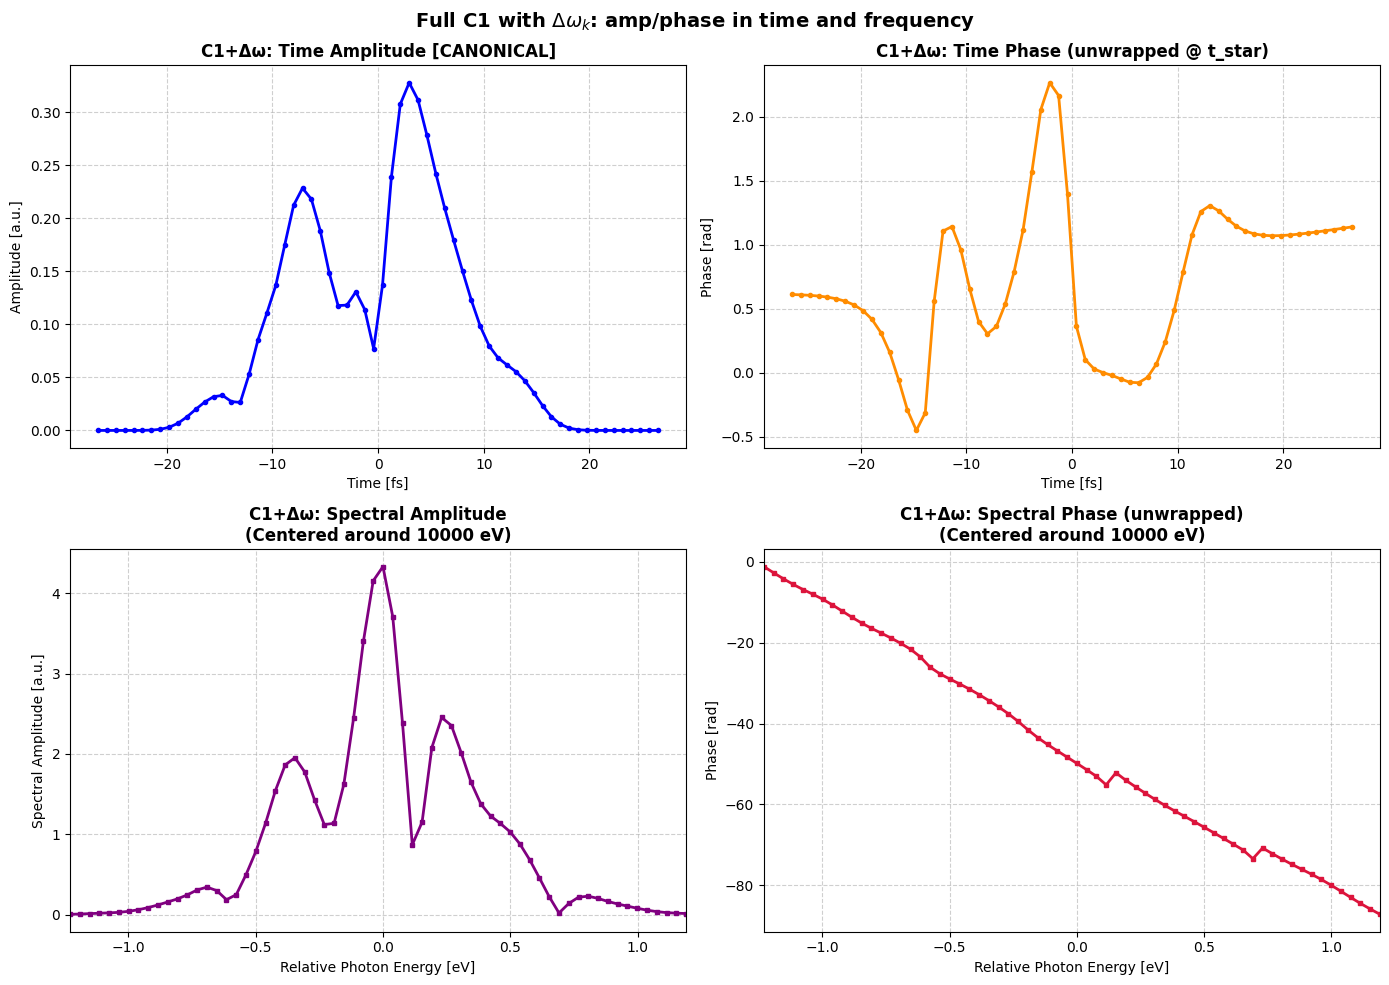

In [8]:
# Full C1 envelope: include Δω_k·(t - t_k) in the per-spike phase
# (carrier ω₀ removed; relative spectral axis matches energy_ev_relative).
from spectral_grid import fft_to_plot_spectrum
from pulse_metrics import canonicalize_field_tstar
from data_generation import phase_t_unwrapped_at_index

f_t_c1_delta = np.zeros(N_POINTS, dtype=complex)
for params in spike_params:
    t_center = params["t_center"]
    amplitude = params["amplitude"]
    random_phase = params["random_phase"]
    delta_omega_i = params["delta_omega_i"]
    dt_spike = t - t_center

    gaussian = np.exp(-(dt_spike ** 2) / (4 * COHERENCE_TIME_AS ** 2))
    # Envelope phase: Δω_k (t - t_k) + θ_k
    # Full physical phase would be (ω₀ + Δω_k)(t - t_k) + θ_k
    phase = delta_omega_i * dt_spike + random_phase
    f_t_c1_delta += amplitude * gaussian * np.exp(1j * phase)

f_t_c1_delta_raw = f_t_c1_delta.copy()
f_t_c1_delta, t_star_c1_delta = canonicalize_field_tstar(f_t_c1_delta, return_t_star=True)
f_v_c1_delta = fft_to_plot_spectrum(f_t_c1_delta, N_FFT, spec_idx)

print("C1+Δω field built from same spike_params.")
print(f"  ||E_raw|| = {np.linalg.norm(f_t_c1_delta_raw):.4f}")
print(f"  t_star = {t_star_c1_delta}  (t={t[t_star_c1_delta]:.3f} fs)")
print(f"  |phase(t_star)| = {abs(np.angle(f_t_c1_delta[t_star_c1_delta])):.3e} rad")
print(f"  Δω_max = {DELTA_OMEGA_MAX:.6e} rad/fs")

# Amplitude & phase: time + spectrum (same layout as Visualization)
amp_t = np.abs(f_t_c1_delta)
phase_t = phase_t_unwrapped_at_index(f_t_c1_delta, t_star_c1_delta)
amp_v = np.abs(f_v_c1_delta)
phase_v = np.unwrap(np.angle(f_v_c1_delta))

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

axs[0, 0].plot(t, amp_t, color="blue", lw=2, marker="o", markersize=3)
axs[0, 0].set_title("C1+Δω: Time Amplitude [CANONICAL]", fontweight="bold")
axs[0, 0].set_xlabel("Time [fs]")
axs[0, 0].set_ylabel("Amplitude [a.u.]")
axs[0, 0].grid(True, linestyle="--", alpha=0.6)

axs[0, 1].plot(t, phase_t, color="darkorange", lw=2, marker="o", markersize=3)
axs[0, 1].set_title("C1+Δω: Time Phase (unwrapped @ t_star)", fontweight="bold")
axs[0, 1].set_xlabel("Time [fs]")
axs[0, 1].set_ylabel("Phase [rad]")
axs[0, 1].grid(True, linestyle="--", alpha=0.6)

axs[1, 0].plot(energy_ev_relative, amp_v, color="purple", lw=2, marker="s", markersize=3)
axs[1, 0].set_title(
    f"C1+Δω: Spectral Amplitude\n(Centered around {CENTRAL_ENERGY_EV:g} eV)",
    fontweight="bold",
)
axs[1, 0].set_xlabel("Relative Photon Energy [eV]")
axs[1, 0].set_ylabel("Spectral Amplitude [a.u.]")
axs[1, 0].set_xlim(float(energy_ev_relative[0]), float(energy_ev_relative[-1]))
axs[1, 0].grid(True, linestyle="--", alpha=0.6)

axs[1, 1].plot(energy_ev_relative, phase_v, color="crimson", lw=2, marker="s", markersize=3)
axs[1, 1].set_title(
    f"C1+Δω: Spectral Phase (unwrapped)\n(Centered around {CENTRAL_ENERGY_EV:g} eV)",
    fontweight="bold",
)
axs[1, 1].set_xlabel("Relative Photon Energy [eV]")
axs[1, 1].set_ylabel("Phase [rad]")
axs[1, 1].set_xlim(float(energy_ev_relative[0]), float(energy_ev_relative[-1]))
axs[1, 1].grid(True, linestyle="--", alpha=0.6)

fig.suptitle(
    r"Full C1 with $\Delta\omega_k$: amp/phase in time and frequency",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
